# ___Data wrangling for the paper draft; with `FRED 4.0`___
--------------------------------------

In [1]:
!python --version

Python 3.14.5


The system cannot find the path specified.


In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.typing import NDArray
from numba import njit, vectorize, float32, float64
from scipy.stats import pearsonr, sem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [3]:
# including all the traits Luke advised

COLLABORATION_GRADIENT_TRAITS = [
    "F00679", # RD
    "F00727", # SRL
    # "F00104", # RCT
]

CONSERVATION_GRADIENT_TRAITS = [
    "F00709", # RTD
    # "F00261", # RN
]

CHOSEN_ROOT_TRAITS = COLLABORATION_GRADIENT_TRAITS + CONSERVATION_GRADIENT_TRAITS

CHOSEN_TRAITS_DICT = {
    "F00709":  "RTD",
    # "F00261":  "RN",
    "F00679":  "RD",
    "F00727":  "SRL",
    # "F00104":  "RCT",
}

PLANT_TAXONOMY_ACCEPTED_COLUMNS = [
    "F01286", # Genus of plant according to The Plant List
    "F01287", # Species epithet of plant according to The Plant List
    "F01289", # Family of plant according to The Plant List
    "F01290"  # Order of plant.
]

BINOMINAL_NAME = ["F01286", "F01287"]

BINOMINAL_NAME_DATA_SOURCE = ["F00018", "F00019"]

MISC = [
    "F00056", # root order
    "F00645", # Mycorrhiza_Type_Data source
   # "F01282" # Mycorrhiza_Type_Maherali - not present in FRED 4.0
]

TAXONOMY_COLUMNS_TO_CROSSCHECK = [
    "F01289", "F01290", # from FRED 4.0
    "family", "order", "group" # from the lookup table
]

# families Luke advised as important
FAMILIES_NOT_TO_MISS = ("Zamiaceae", "Cycadaceae", "Magnoliaceae", "Lauraceae", # generally thick rooted absorptive roots
                       "Cyperaceae", "Brassicaceae") # NM families

In [4]:
fred = pd.read_csv(r"../../data/chapter2/FRED/FRED4_Entire_Database_2026.csv", low_memory=False, header=0, skiprows=range(1, 7), encoding="latin1") # FRED 4.0
meta = pd.read_csv(r"../../data/chapter2/FRED/FRED3_Column_Definitions_2021.csv", usecols=["column_id", "name", "units"], index_col="column_id")

lookup = pd.read_csv(r"../../data/chapter2/plant_lookup.csv", low_memory=False, encoding="latin1", usecols=["genus", "apweb.family", # let's stick the the family info from APG website
                                                                                                         "order", "group"], index_col="genus").rename(mapper={"apweb.family": "family"}, axis=1) 

# thought we could use the data source's binominal names where FRED's binominal names are missing but looks like that won't help :/
# drop all the rows that do not have genus and species names
fred.dropna(subset=BINOMINAL_NAME, inplace=True)

# strip off all the unnecessary spaces
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS] = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].apply(lambda col: col.str.strip())

In [5]:
meta.loc[PLANT_TAXONOMY_ACCEPTED_COLUMNS + BINOMINAL_NAME_DATA_SOURCE + CHOSEN_ROOT_TRAITS + MISC, :]

,name,units
column_id,,
F01286,Plant taxonomy_Accepted genus_TPL,NaN
F01287,Plant Taxonomy_Accepted species_TPL,NaN
F01289,Plant taxonomy_Accepted family_TPL,NaN
F01290,Plant taxonomy_Accepted order_APW,NaN
F00018,Plant taxonomy_Genus_Data Source,NaN
F00019,Plant taxonomy_Species_Data source,NaN
F00679,Root diameter,mm
F00727,Specific root length (SRL),m/g
F00709,Root tissue density (RTD),g/cm3


In [6]:
# records with missing binominal names aren't useful to us 
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].isna().mean() # dropna(subset=BINOMINAL_NAME)

F01286    0.000000
F01287    0.000000
F01289    0.000000
F01290    0.000000
F00679    0.796387
F00727    0.796594
F00709    0.844053
dtype: float64

In [105]:
# that many records with missing binominal names???
fred.loc[:, BINOMINAL_NAME + BINOMINAL_NAME_DATA_SOURCE].isna().sum()

F01286     0
F01287     0
F00018     0
F00019    60
dtype: int64

### ___$1^{st}$ order roots___
__________________

In [109]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS + MISC].query(r"F00056==1")

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056,F00645
0,Dicranopteris,linearis,Gleicheniaceae,Gleicheniales,NaN,NaN,NaN,1.0,AM
3,Cunninghamia,lanceolata,Cupressaceae,Cupressales,NaN,NaN,NaN,1.0,AM
6,Magnolia,baillonii,Magnoliaceae,Magnoliales,NaN,NaN,NaN,1.0,AM
11,Acacia,auriculiformis,Fabaceae,Fabales,NaN,NaN,NaN,1.0,AM
15,Polyspora,axillaris,Theaceae,Ericales,NaN,NaN,NaN,1.0,AM
...,...,...,...,...,...,...,...,...,...
70350,Pinus,strobus,Pinaceae,Pinales,0.421385,17.805402,0.337226,1.0,EM
70354,Tsuga,canadensis,Pinaceae,Pinales,0.373780,30.873103,0.204034,1.0,EM
70358,Sciadopitys,verticillata,Sciadopityaceae,Cupressales,0.620386,29.212460,0.125136,1.0,AM
70363,Cephalotaxus,harringtonii,Cephalotaxaceae,Cupressales,0.626291,21.950489,0.125251,1.0,AM


In [110]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS + MISC].query(r"F00056==1").loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
0,Dicranopteris,linearis
3,Cunninghamia,lanceolata
6,Magnolia,baillonii
11,Acacia,auriculiformis
15,Polyspora,axillaris
...,...,...
70295,Encephalartos,gratus
70299,Zamia,lucayana
70303,Chamaecyparis,pisifera
70328,Ephedra,distachya


In [111]:
fred.loc[:, CHOSEN_ROOT_TRAITS + MISC].query(r"F00056==1").isna().mean().rename(index=CHOSEN_TRAITS_DICT)

RD        0.266157
SRL       0.668451
RTD       0.726195
F00056    0.000000
F00645    0.738815
dtype: float64

### ___RD $\le$ 2.0 mm___
-----------------------

In [112]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 2.000").dropna(subset=CHOSEN_ROOT_TRAITS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
236,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286
237,Larix,gmelinii,Pinaceae,Pinales,0.411555,25.480815,0.294286
238,Larix,gmelinii,Pinaceae,Pinales,0.527621,12.980828,0.382857
239,Larix,gmelinii,Pinaceae,Pinales,0.846975,6.250067,0.334286
241,Larix,gmelinii,Pinaceae,Pinales,0.307450,34.615414,0.382857
...,...,...,...,...,...,...,...
71902,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.740062,8.685170,0.224091
71903,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.739066,8.855820,0.228155
71904,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.666566,9.584048,0.228379
71905,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.639820,10.362667,0.265331


In [113]:
# focusing on rows that have data for all the three traits
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 2.000").dropna(subset=CHOSEN_ROOT_TRAITS).loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
236,Larix,gmelinii
266,Fraxinus,mandshurica
382,Populus,trichocarpa
386,Populus,tremula
827,Cinnamomum,micranthum
...,...,...
71813,Sorocea,muriculata
71814,Stachyarrhena,acuminata
71815,Trymatococcus,amazonicus
71816,Zygia,inaequalis


In [114]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 2.000").dropna(subset=CHOSEN_ROOT_TRAITS).isna().mean().rename(index=CHOSEN_TRAITS_DICT)

F01286    0.0
F01287    0.0
F01289    0.0
F01290    0.0
RD        0.0
SRL       0.0
RTD       0.0
dtype: float64

In [116]:
# inspect the coverage of thick rooted families in this subset
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
827,Cinnamomum,micranthum,Lauraceae,Laurales,0.502558,24.150012,0.209434
832,Magnolia,odora,Magnoliaceae,Magnoliales,0.500991,24.405710,0.206190
837,Cinnamomum,chekiangense,Lauraceae,Laurales,0.499444,23.180490,0.214529
1450,Cryptocarya,chinensis,Lauraceae,Laurales,1.177410,9.677503,0.248276
1572,Gahnia,procera,Cyperaceae,Poales,0.320000,58.700000,0.190000
...,...,...,...,...,...,...,...
71756,Ocotea,scabrella,Lauraceae,Laurales,0.726000,9.060000,0.275000
71757,Ocotea,splendens,Lauraceae,Laurales,0.589000,11.920000,0.321000
71804,Rhodostemonodaphne,crenaticupula,Lauraceae,Laurales,0.703000,7.990000,0.382000
71805,Rhodostemonodaphne,paniculata,Lauraceae,Laurales,0.714000,4.670000,0.479000


In [117]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
        groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,18
Cycadaceae,2
Cyperaceae,17
Lauraceae,111
Magnoliaceae,29
Zamiaceae,3


In [118]:
cutoff_2mm_taxa = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000)").dropna(subset=CHOSEN_ROOT_TRAITS).loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].\
    drop_duplicates(subset=BINOMINAL_NAME).sort_values(["F01289", "F01290", "F01286", "F01287"]).reset_index(drop=True)
cutoff_2mm_taxa

,F01286,F01287,F01289,F01290
0,Strobilanthes,dimorphotricha,Acanthaceae,Lamiales
1,Actinidia,kolomikta,Actinidiaceae,Ericales
2,Saurauia,herthae,Actinidiaceae,Ericales
3,Liquidambar,formosana,Altingiaceae,Saxifragales
4,Liquidambar,gracilipes,Altingiaceae,Saxifragales
...,...,...,...,...
1435,Dioon,rzedowskii,Zamiaceae,Cycadales
1436,Encephalartos,gratus,Zamiaceae,Cycadales
1437,Zamia,lucayana,Zamiaceae,Cycadales
1438,Alpinia,japonica,Zingiberaceae,Zingiberales


In [119]:
# WE HAVE SPECIES CLASSIFIED UNDER DIFFERENT HIGHER TAXA IN THIS SUBSET!!!!!

### ___RD $\le$ 1.00 mm___
------------------

In [120]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 1.000").dropna(subset=CHOSEN_ROOT_TRAITS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
236,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286
237,Larix,gmelinii,Pinaceae,Pinales,0.411555,25.480815,0.294286
238,Larix,gmelinii,Pinaceae,Pinales,0.527621,12.980828,0.382857
239,Larix,gmelinii,Pinaceae,Pinales,0.846975,6.250067,0.334286
241,Larix,gmelinii,Pinaceae,Pinales,0.307450,34.615414,0.382857
...,...,...,...,...,...,...,...
71902,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.740062,8.685170,0.224091
71903,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.739066,8.855820,0.228155
71904,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.666566,9.584048,0.228379
71905,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.639820,10.362667,0.265331


In [121]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 1.000").dropna(subset=CHOSEN_ROOT_TRAITS).loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
236,Larix,gmelinii
266,Fraxinus,mandshurica
382,Populus,trichocarpa
386,Populus,tremula
827,Cinnamomum,micranthum
...,...,...
71813,Sorocea,muriculata
71814,Stachyarrhena,acuminata
71815,Trymatococcus,amazonicus
71816,Zygia,inaequalis


In [122]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 1.000").dropna(subset=CHOSEN_ROOT_TRAITS).isna().mean().rename(index=CHOSEN_TRAITS_DICT)

F01286    0.0
F01287    0.0
F01289    0.0
F01290    0.0
RD        0.0
SRL       0.0
RTD       0.0
dtype: float64

In [123]:
# inspect the thick rooted family coverage
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
827,Cinnamomum,micranthum,Lauraceae,Laurales,0.502558,24.150012,0.209434
832,Magnolia,odora,Magnoliaceae,Magnoliales,0.500991,24.405710,0.206190
837,Cinnamomum,chekiangense,Lauraceae,Laurales,0.499444,23.180490,0.214529
1572,Gahnia,procera,Cyperaceae,Poales,0.320000,58.700000,0.190000
1573,Gahnia,xanthocarpa,Cyperaceae,Poales,0.460000,45.600000,0.100000
...,...,...,...,...,...,...,...
71756,Ocotea,scabrella,Lauraceae,Laurales,0.726000,9.060000,0.275000
71757,Ocotea,splendens,Lauraceae,Laurales,0.589000,11.920000,0.321000
71804,Rhodostemonodaphne,crenaticupula,Lauraceae,Laurales,0.703000,7.990000,0.382000
71805,Rhodostemonodaphne,paniculata,Lauraceae,Laurales,0.714000,4.670000,0.479000


In [124]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,5
Cycadaceae,2
Cyperaceae,12
Lauraceae,96
Magnoliaceae,28
Zamiaceae,3


In [125]:
# diff in species counts, all three traits

fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"}) - fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,13
Cycadaceae,0
Cyperaceae,5
Lauraceae,15
Magnoliaceae,1
Zamiaceae,0


In [126]:
# diff in species counts, RD & SRL

fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=COLLABORATION_GRADIENT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"}) - fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=COLLABORATION_GRADIENT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,14
Cycadaceae,0
Cyperaceae,5
Lauraceae,15
Magnoliaceae,1
Zamiaceae,0


In [127]:
# dropping NaNs only in RD and SRL

cutoff_1mm_taxa = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000)").dropna(subset=COLLABORATION_GRADIENT_TRAITS).loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].\
    drop_duplicates(subset=BINOMINAL_NAME).sort_values(["F01289", "F01290", "F01286", "F01287"]).reset_index(drop=True)
cutoff_1mm_taxa

,F01286,F01287,F01289,F01290
0,Rungia,pectinata,Acanthaceae,Lamiales
1,Strobilanthes,dimorphotricha,Acanthaceae,Lamiales
2,Actinidia,kolomikta,Actinidiaceae,Ericales
3,Saurauia,herthae,Actinidiaceae,Ericales
4,Liquidambar,formosana,Altingiaceae,Saxifragales
...,...,...,...,...
1439,Dioon,rzedowskii,Zamiaceae,Cycadales
1440,Encephalartos,gratus,Zamiaceae,Cycadales
1441,Zamia,lucayana,Zamiaceae,Cycadales
1442,Alpinia,japonica,Zingiberaceae,Zingiberales


In [33]:
# SUSPECT THIS SUBSET ALSO HAS SPECIES CLASSIFIED UNDER MULTIPLE HIGHER RANKS!!!!!!!!

In [128]:
# see what species we are losing going from 2mm to 1mm cutoff

species_lost_2mm_to_1mm = np.setdiff1d(cutoff_2mm_taxa.loc[:, BINOMINAL_NAME].apply(' '.join, axis=1).unique(), 
                                        cutoff_1mm_taxa.loc[:, BINOMINAL_NAME].apply(' '.join, axis=1).unique())# .size
species_lost_2mm_to_1mm

array(['Aglaia squamulosa', 'Agrostis stolonifera', 'Alchemilla arvensis',
       'Alchemilla xanthochlora', 'Alopecurus geniculatus',
       'Aniba citrifolia', 'Aniba williamsii', 'Arabidopsis arenosa',
       'Arabidopsis thaliana', 'Arabis sagittata', 'Barbarea vulgaris',
       'Beilschmiedia brachythyrsa', 'Beilschmiedia percoriacea',
       'Beilschmiedia robusta', 'Bellis perennis', 'Berula erecta',
       'Brassica rapa', 'Briza media', 'Bromus sterilis',
       'Calamagrostis canescens', 'Campanula glomerata',
       'Campanula patula', 'Campanula persicifolia',
       'Campanula rapunculoides', 'Capsella bursa-pastoris',
       'Cardamine pratensis', 'Carex leporina', 'Carex muricata',
       'Carex ornithopoda', 'Carex praecox', 'Carex vulpina',
       'Centaurium erythraea', 'Cerastium glomeratum',
       'Cerastium pumilum', 'Cerastium semidecandrum',
       'Clinopodium acinos', 'Clusia latipes', 'Cruciata laevipes',
       'Cryptocarya densiflora', 'Cynanchica pyrenaica

In [35]:
species_lost_2mm_to_1mm = pd.DataFrame({"F01286": [_.split()[0] for _ in species_lost_2mm_to_1mm], "F01287": [_.split()[1] for _ in species_lost_2mm_to_1mm]})
species_lost_2mm_to_1mm

,F01286,F01287
0,Aglaia,squamulosa
1,Agrostis,stolonifera
2,Alchemilla,arvensis
3,Alchemilla,xanthochlora
4,Alopecurus,geniculatus
...,...,...
134,Veronica,officinalis
135,Veronica,serpyllifolia
136,Veronica,spicata
137,Viola,arvensis


In [36]:
# full taxonomic profile of the 139 species
species_lost_2mm_to_1mm = pd.merge(left=species_lost_2mm_to_1mm, left_on=BINOMINAL_NAME, right=cutoff_2mm_taxa, right_on=BINOMINAL_NAME, how="left").sort_values(["F01289", "F01290"] + BINOMINAL_NAME).reset_index(drop=True)
species_lost_2mm_to_1mm

,F01286,F01287,F01289,F01290
0,Berula,erecta,Apiaceae,Apiales
1,Ruscus,aculeatus,Asparagaceae,Asparagales
2,Bellis,perennis,Asteraceae,Asterales
3,Erigeron,acris,Asteraceae,Asterales
4,Hypochaeris,radicata,Asteraceae,Asterales
...,...,...,...,...
134,Galium,pumilum,Rubiaceae,Gentianales
135,Galium,verum,Rubiaceae,Gentianales
136,Sherardia,arvensis,Rubiaceae,Gentianales
137,Saxifraga,tridactylites,Saxifragaceae,Saxifragales


In [96]:
species_lost_2mm_to_1mm.to_csv(r"../../data/chapter2/FRED/subsets/species_lost_2mm_to_1mm_FRED4.csv", index=False)

In [39]:
# that's a lot of useful species
species_lost_2mm_to_1mm.query(r"F01289.isin(@FAMILIES_NOT_TO_MISS)").drop_duplicates()

,F01286,F01287,F01289,F01290
10,Arabidopsis,arenosa,Brassicaceae,Brassicales
11,Arabidopsis,thaliana,Brassicaceae,Brassicales
12,Arabis,sagittata,Brassicaceae,Brassicales
13,Barbarea,vulgaris,Brassicaceae,Brassicales
14,Brassica,rapa,Brassicaceae,Brassicales
15,Capsella,bursa-pastoris,Brassicaceae,Brassicales
16,Cardamine,pratensis,Brassicaceae,Brassicales
17,Erophila,verna,Brassicaceae,Brassicales
18,Lepidium,campestre,Brassicaceae,Brassicales
19,Sinapis,arvensis,Brassicaceae,Brassicales


In [129]:
# decide which columns in FRED 4.0 have mycorrhizal state info????
[col for col in fred.columns if ((fred.loc[:, col].dtype == pd.StringDtype(storage="python", na_value=np.nan)) and fred.loc[:, col].str.contains("AM").any())]

['F00004', 'F00006', 'F00043', 'F00645', 'F01160', 'F00079']

In [130]:
fred.loc[:, ('F00004', 'F00006', 'F00043', 'F00645', 'F01160', 'F00079')]

,F00004,F00006,F00043,F00645,F01160,F00079
0,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",NaN,C3,AM,NaN,NaN
1,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",NaN,C3,AM,NaN,NaN
2,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",NaN,C3,AM,NaN,NaN
3,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",NaN,C3,AM,NaN,NaN
4,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",NaN,C3,AM,NaN,NaN
...,...,...,...,...,...,...
77554,"Kutschera L, Lichtenegger E, Sobotik M, Haas D...","Tumber-Davila SJ, Schenk HJ, Du E, and Jackson...",NaN,NaN,NaN,NaN
77555,"Kutschera L, Lichtenegger E (1960) Wurzelatlas...","Tumber-Davila SJ, Schenk HJ, Du E, and Jackson...",C3,NaN,NaN,NaN
77556,"Kutschera L, Lichtenegger E, Sobotik M, Haas D...","Tumber-Davila SJ, Schenk HJ, Du E, and Jackson...",NaN,NaN,NaN,NaN
77557,"Kutschera L, Lichtenegger E (1960) Wurzelatlas...","Tumber-Davila SJ, Schenk HJ, Du E, and Jackson...",C3,NaN,NaN,NaN


In [39]:
fred.loc[:, ('F00645', 'F01160', 'F00079')].dropna() # damn, FRED 3 has a row F01282 named Mycorrhiza_Type_Maherali, but FRED 4 hasn't

,F00645,F01160,F00079
1651,AM,control,RLD converted from 1m depth to 0.3m depth. Dat...
1656,AM,control,RLD converted from 1m depth to 0.3m depth. Dat...
1661,AM,control,RLD converted from 1m depth to 0.3m depth. Dat...
3581,EM,ambient CO2,"Diameter, diameter production, and diameter mo..."
3582,EM,ambient CO2,"Diameter, diameter production, and diameter mo..."
...,...,...,...
54022,AM,N10,AM colonization taken from graph using Grab It...
55131,AM,control,Plant species categorical data not found in TR...
55134,AM,control,Plant species categorical data not found in TR...
55140,AM,control,Plant species categorical data not found in TR...


### ___Choosing to proceed with an RD cutoff $\le$ 1.00 mm___
---------------------------------------------------------------------------------------

In [28]:
# final subset for the phylogenetics work; using traits - RD, SRL and RTD and using RD <= 1.00 mm as the cutoff criteria

subset = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS + MISC].query(r"F00679 <= 1.000").reset_index(drop=True)
subset

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056,F00645
0,Populus,tremuloides,Salicaceae,Malpighiales,0.220000,NaN,NaN,NaN,NaN
1,Acer,negundo,Sapindaceae,Sapindales,0.280000,NaN,NaN,NaN,NaN
2,Juglans,nigra,Juglandaceae,Fagales,0.300000,NaN,NaN,NaN,NaN
3,Quercus,rubra,Fagaceae,Fagales,0.230000,NaN,NaN,NaN,NaN
4,Carya,glabra,Juglandaceae,Fagales,0.220000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9679,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.740062,8.685170,0.224091,NaN,AM
9680,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.739066,8.855820,0.228155,NaN,AM
9681,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.666566,9.584048,0.228379,NaN,AM
9682,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.639820,10.362667,0.265331,NaN,AM


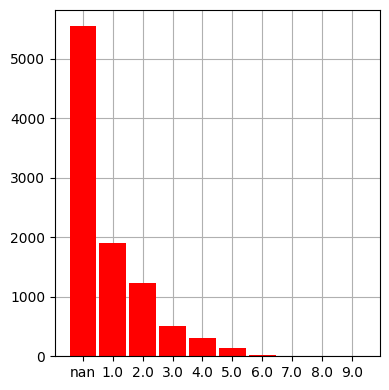

In [29]:
# examine the root orders within this RD <= 1.00 mm subset

freq = subset.F00056.value_counts(dropna=False)
fig, axes = plt.subplots()
fig.set_size_inches(4, 4)
axes.bar(x=freq.index.fillna(0), # without replacing with 0s, NaNs get ignored in x???
         height=freq.values, width=0.9, color="red")
axes.grid()
axes.set_axisbelow(True)
axes.set_xticks(ticks=np.linspace(start=0, stop=freq.size - 1, num=freq.size), labels=freq.index)
plt.tight_layout()
plt.show()

In [30]:
# drop records where root order is > 3 ???
# this is concerning but Luke advised against mixing the two approaches
subset.query(r"F00056 > 3")

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056,F00645
14,Acer,saccharum,Sapindaceae,Sapindales,0.220000,70.500000,NaN,4.0,NaN
15,Acer,saccharum,Sapindaceae,Sapindales,0.210000,83.100000,NaN,5.0,NaN
16,Acer,saccharum,Sapindaceae,Sapindales,0.200000,131.100000,NaN,6.0,NaN
17,Acer,saccharum,Sapindaceae,Sapindales,0.230000,80.200000,NaN,7.0,NaN
20,Fraxinus,americana,Oleaceae,Lamiales,0.210000,108.200000,NaN,4.0,NaN
...,...,...,...,...,...,...,...,...,...
7501,Vitis,vinifera,Vitaceae,Vitales,0.371517,0.480000,NaN,4.0,AM
7502,Vitis,vinifera,Vitaceae,Vitales,0.590948,0.090000,NaN,5.0,AM
7506,Vitis,vinifera,Vitaceae,Vitales,0.600550,0.290000,NaN,4.0,AM
9001,Dacrydium,balansae,Podocarpaceae,Araucariales,0.847640,6.220949,0.526719,4.0,AM


In [31]:
subset.loc[:, BINOMINAL_NAME].drop_duplicates() # that's a good number of species

,F01286,F01287
0,Populus,tremuloides
1,Acer,negundo
2,Juglans,nigra
3,Quercus,rubra
4,Carya,glabra
...,...,...
9591,Sorocea,muriculata
9592,Stachyarrhena,acuminata
9593,Trymatococcus,amazonicus
9594,Zygia,inaequalis


In [32]:
# species record with values for RD, SRL & RTD
subset.dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056,F00645
69,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286,1.0,NaN
92,Fraxinus,mandshurica,Oleaceae,Lamiales,0.288462,78.846169,0.231206,1.0,NaN
128,Populus,trichocarpa,Salicaceae,Malpighiales,0.142951,447.167648,0.169294,1.0,NaN
132,Populus,tremula,Salicaceae,Malpighiales,0.175513,330.424588,0.169294,1.0,NaN
358,Cinnamomum,micranthum,Lauraceae,Laurales,0.502558,24.150012,0.209434,1.0,NaN
...,...,...,...,...,...,...,...,...,...
9591,Sorocea,muriculata,Moraceae,Rosales,0.643000,8.540000,0.469000,NaN,AM
9592,Stachyarrhena,acuminata,Rubiaceae,Gentianales,0.376000,20.890000,0.416000,NaN,AM
9593,Trymatococcus,amazonicus,Moraceae,Rosales,0.581000,7.460000,0.531000,NaN,AM
9594,Zygia,inaequalis,Fabaceae,Fabales,0.367000,26.160000,0.362000,NaN,AM


In [33]:
# Luke advised that if a record has SRL & RD, RTD can be back calculated, so we can just filter out NaNs in SRL and RD??
# species records with values for both RD & SRL
#---------------------------------------------------------------------------------------------------------------------------

subset.dropna(subset=COLLABORATION_GRADIENT_TRAITS).drop_duplicates(subset=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056,F00645
12,Acer,saccharum,Sapindaceae,Sapindales,0.450000,11.500000,NaN,2.0,NaN
18,Fraxinus,americana,Oleaceae,Lamiales,0.670000,9.800000,NaN,2.0,NaN
23,Viola,pubescens,Violaceae,Malpighiales,0.640000,13.000000,NaN,2.0,NaN
27,Hydrophyllum,canadense,Boraginaceae,Boraginales,0.870000,16.200000,NaN,2.0,NaN
69,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286,1.0,NaN
...,...,...,...,...,...,...,...,...,...
9591,Sorocea,muriculata,Moraceae,Rosales,0.643000,8.540000,0.469000,NaN,AM
9592,Stachyarrhena,acuminata,Rubiaceae,Gentianales,0.376000,20.890000,0.416000,NaN,AM
9593,Trymatococcus,amazonicus,Moraceae,Rosales,0.581000,7.460000,0.531000,NaN,AM
9594,Zygia,inaequalis,Fabaceae,Fabales,0.367000,26.160000,0.362000,NaN,AM


In [34]:
subset.dropna(subset=COLLABORATION_GRADIENT_TRAITS).loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
12,Acer,saccharum
18,Fraxinus,americana
23,Viola,pubescens
27,Hydrophyllum,canadense
69,Larix,gmelinii
...,...,...
9591,Sorocea,muriculata
9592,Stachyarrhena,acuminata
9593,Trymatococcus,amazonicus
9594,Zygia,inaequalis


In [35]:
# proceed with records that have data for RD & SRL; where RTD, will be filled using back calculations
#-----------------------------------------------------------------------------------------------------------

subset.dropna(subset=COLLABORATION_GRADIENT_TRAITS, inplace=True)
subset.isna().sum()

F01286       0
F01287       0
F01289       0
F01290       0
F00679       0
F00727       0
F00709    1208
F00056    4564
F00645    3930
dtype: int64

According to [Specific root length as an indicator of environmental change](https://www.tandfonline.com/doi/full/10.1080/11263500701626069);   

Specific root length is the length of a unit mass root segment $SRL = \frac{L}{M}$. But, mass is obviously equal to volume multiplied by density; $M = V \times RTD$. So; $SRL = \frac{L}{V \times RTD}$. Assuming a cylindrical shape, the volume `V` of an `L` length root fragment with `RD` diameter is, $V = \pi \times (\frac{RD}{2})^2 \times L$.  
That makes; $SRL = \frac{L}{\pi \times (\frac{RD}{2})^2 \times L \times RTD} = \frac{4}{\pi \times RD^2 \times RTD}$.  
Hence $RTD = \frac{4}{\pi \times RD^2 \times SRL}$.

In [36]:
@njit(fastmath=True)
def back_calculate_rtd(rd: NDArray[np.float64], srl: NDArray[np.float64]) -> NDArray[np.float64]:
    """
    reference: Ostonen, I. et al. (2007) ‘Specific root length as an indicator of environmental change’,
    Plant Biosystems - An International Journal Dealing with all Aspects of Plant Biology, 141(3), pp. 426–442.
    Available at: https://doi.org/10.1080/11263500701626069.

    FRED uses the following units for the following traits::
    Root diameter -	mm
    Specific root length - m/g
 	Root tissue density - g/cm3

    we need to reconcile the units before applying the equation!, the target (RTD) is in g/cm3, so change all the lengths to cm.
    RD (mm) => RD/10 (cm)
    SRL (m/g) => SRL * 100 (cm/g)

    so the equation becomes: 4.0000 / (pi * (RD/10)^2 * SRL * 100)
    so the output RTD will be in units => g/cm3
    """
    
    return 4.00000 / (np.pi * np.square(rd/10) * (srl * 100))

back_calculate_rtd = np.vectorize(pyfunc=back_calculate_rtd, otypes=[np.float64])

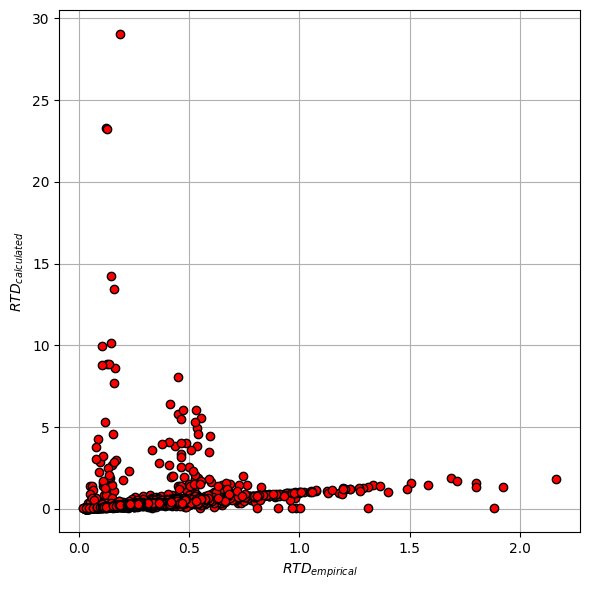

In [37]:
# before we fill the NaNs in RTD with calculated values, check how close our calculations are to actual values where RTD data is available
# this is pre log transformation of the traits

all_three_traits = subset.query(r"not F00709.isna()").loc[:, CHOSEN_ROOT_TRAITS]

fig, axes = plt.subplots()
fig.set_size_inches(6, 6)
axes.scatter(x=all_three_traits.F00709, y=back_calculate_rtd(all_three_traits.F00679.values, all_three_traits.F00727.values), color="red", edgecolor="black")
axes.set_xlabel(r"$RTD_{empirical}$")
axes.set_ylabel(r"$RTD_{calculated}$")
axes.set_axisbelow(True)
axes.grid()
plt.tight_layout()
plt.show()

In [38]:
# that's concerningly low????
pearsonr(x=all_three_traits.F00709, y=back_calculate_rtd(all_three_traits.F00679.values, all_three_traits.F00727.values))

PearsonRResult(statistic=np.float64(0.1940890421715866), pvalue=np.float64(1.8262099893534333e-45))

In [39]:
# try fitting a linear regression model instead of using the equation???

mmax_scaler = MinMaxScaler()
scaled_x = mmax_scaler.fit_transform(X=all_three_traits.loc[:, ["F00679", "F00727"]], y=all_three_traits.F00709)

# split the dataset into training set and testing set
scaled_x_train, scaled_x_test, y_train, y_test = train_test_split(scaled_x, all_three_traits.F00709, train_size=0.70)

lmod = LinearRegression(n_jobs=12)
lmod.fit(X=scaled_x_train, y=y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",12
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-0.27,-1.25]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.5005
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[13.11, 3.53]"


In [40]:
lmod.predict(scaled_x_test) # hope it didn't memoize the train values

array([0.32117275, 0.32779751, 0.34366444, ..., 0.3187232 , 0.098265  ,
       0.24323501], shape=(1566,))

In [41]:
pearsonr(x=y_test, y=lmod.predict(scaled_x_test)) # that sucks too :/

PearsonRResult(statistic=np.float64(0.3976283469237349), pvalue=np.float64(1.7954771475806954e-60))

In [42]:
# try a polynomial regression

polyfeats = PolynomialFeatures(degree=8)
mmax_scaler = MinMaxScaler()

scaled_x = mmax_scaler.fit_transform(X=all_three_traits.loc[:, ["F00679", "F00727"]], y=all_three_traits.F00709)
scaled_poly_x = polyfeats.fit_transform(scaled_x)

x_train, x_test, y_train, y_test = train_test_split(scaled_poly_x, all_three_traits.F00709, train_size=0.7)

polymod = LinearRegression(n_jobs=12)
polymod.fit(X=x_train, y=y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",12
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](45,)","[ -0. , 19.08, 31.85,...,-9915.95, 2996.56, 1939.08]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.026
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,45
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,33
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](45,)","[32.16, 8.96, 4.2 ,..., 0. , 0. , 0. ]"


In [43]:
# THE CORRELATION COEFFICIENT VARIES DRASTICALLY BETWEEN MODEL FITS?????
pearsonr(x=y_test, y=polymod.predict(x_test)) # that interesting????

PearsonRResult(statistic=np.float64(0.20431919364892331), pvalue=np.float64(3.2065503295462175e-16))

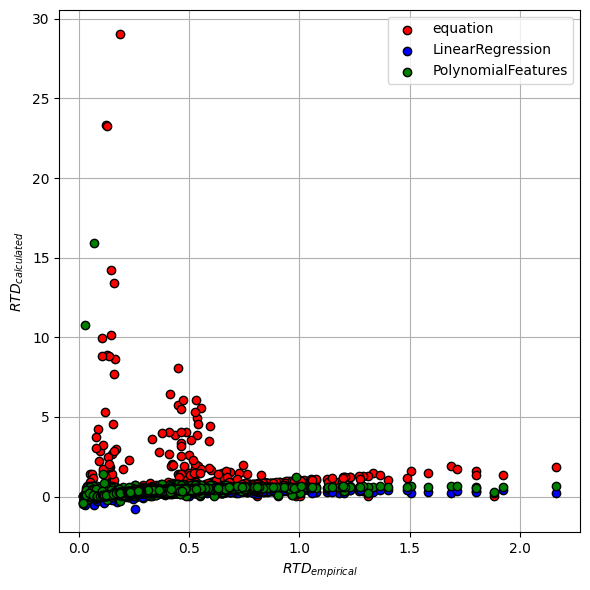

In [44]:
fig, axes = plt.subplots()
fig.set_size_inches(6, 6)
axes.scatter(x=all_three_traits.F00709, y=back_calculate_rtd(all_three_traits.F00679.values, all_three_traits.F00727.values), color="red", edgecolor="black", label="equation")
axes.scatter(x=all_three_traits.F00709, y=lmod.predict(scaled_x), color="blue", edgecolor="black", label="LinearRegression")
axes.scatter(x=all_three_traits.F00709, y=polymod.predict(scaled_poly_x), color="green", edgecolor="black", label="PolynomialFeatures")
axes.set_xlabel(r"$RTD_{empirical}$")
axes.set_ylabel(r"$RTD_{calculated}$")
axes.legend()
axes.set_axisbelow(True)
axes.grid()
plt.tight_layout()
plt.show()

In [45]:
# CHOOSING NOT TO BACK CALCULATE THE RTD VALUES
#------------------------------------------------

# fill the NaNs in the RTD column with manual calculations
# subset.loc[subset.F00709.isna(), "F00709"] = back_calculate_rtd(rd=subset.query(r"F00709.isna()").loc[:, "F00679"], srl=subset.query(r"F00709.isna()").loc[:, "F00727"])
# subset.isna().sum() # cool 

In [46]:
# abandon the plan to back propagate RTD values and drop the records that have missing RTD values
subset.dropna(subset="F00709", inplace=True)
subset.isna().mean()

F01286    0.000000
F01287    0.000000
F01289    0.000000
F01290    0.000000
F00679    0.000000
F00727    0.000000
F00709    0.000000
F00056    0.721349
F00645    0.589115
dtype: float64

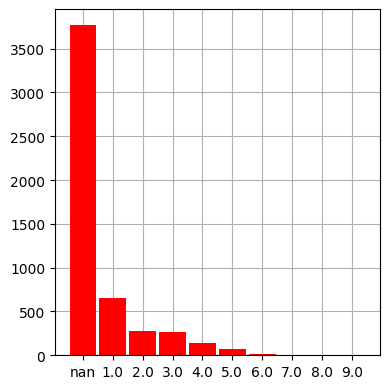

In [47]:
# examine the root orders within this RD <= 1.00 mm subset

freq = subset.F00056.value_counts(dropna=False)
fig, axes = plt.subplots()
fig.set_size_inches(4, 4)
axes.bar(x=freq.index.fillna(0), # without replacing with 0s, NaNs get ignored in x???
         height=freq.values, width=0.9, color="red")
axes.grid()
axes.set_axisbelow(True)
axes.set_xticks(ticks=np.linspace(start=0, stop=freq.size - 1, num=freq.size), labels=freq.index)
plt.tight_layout()
plt.show()

In [48]:
np.setdiff1d(subset.F01286.unique(), lookup.index)

array(['Alseodaphnopsis', 'Andesanthus', 'Austroblechnum',
       'Chrysojasminum', 'Cranfillia', 'Eumachia', 'Helesia',
       'Heptapleurum', 'Hesperostipa', 'Hymenopus', 'Imbralyx',
       'Leptobalanus', 'Pectinopitys', 'Prasoxylon', 'Pseudodictamnus',
       'Rubroshorea', 'Tetrapilus', 'Veronia', 'Wurfbainia'], dtype=object)

In [49]:
# we need to manually cross check these genera

# Austroblechnum
# Cranfillia
# Pectinopitys
# Helesia
# Tetrapilus
# Heptapleurum
# Veronia
# Prasoxylon
# Pseudodictamnus
# Chrysojasminum
# Hesperostipa
# Rubroshorea
# Wurfbainia
# Andesanthus
# Imbralyx
# Alseodaphnopsis
# Hymenopus
# Leptobalanus
# Eumachia

In [50]:
# for the genera that the lookup table has taxonomic data for, do the crosschecking
#------------------------------------------------------------------------------------

lookup_merged = pd.merge(left=subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"F01286.isin(@lookup.index)").drop_duplicates(),
                         left_on="F01286", right=lookup, right_index=True, how="left").reset_index(drop=True)
lookup_merged

,F01286,F01287,F01289,F01290,family,order,group
0,Larix,gmelinii,Pinaceae,Pinales,Pinaceae,Pinales,Gymnosperms
1,Fraxinus,mandshurica,Oleaceae,Lamiales,Oleaceae,Lamiales,Angiosperms
2,Populus,trichocarpa,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms
3,Populus,tremula,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms
4,Cinnamomum,micranthum,Lauraceae,Laurales,Lauraceae,Laurales,Angiosperms
...,...,...,...,...,...,...,...
1269,Sorocea,muriculata,Moraceae,Rosales,Moraceae,Rosales,Angiosperms
1270,Stachyarrhena,acuminata,Rubiaceae,Gentianales,Rubiaceae,Gentianales,Angiosperms
1271,Trymatococcus,amazonicus,Moraceae,Rosales,Moraceae,Rosales,Angiosperms
1272,Zygia,inaequalis,Fabaceae,Fabales,Fabaceae,Fabales,Angiosperms


In [51]:
# family level coflicts
lookup_merged.query(r"F01289!=family").drop_duplicates()

,F01286,F01287,F01289,F01290,family,order,group
32,Hedycarya,arborea,Minimiaceae,Laurales,Monimiaceae,Laurales,Angiosperms
112,Nyssa,sylvatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
367,Sambucus,williamsii,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
504,Viburnum,dentatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
531,Apodytes,dimidiata,Metteniusaceae,Metteniusales,Icacinaceae,Icacinales,Angiosperms
631,Viburnum,tinus,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
700,Galearia,maingayi,Fabaceae,Fabales,Pandaceae,Malpighiales,Angiosperms
706,Nyssa,aquatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
875,Viburnum,stipitatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
1004,Cephalotaxus,harringtonii,Cephalotaxaceae,Cupressales,Taxaceae,Pinales,Gymnosperms


In [52]:
# spelling mistakes in FRED are indicated with and asterisk*

# taxa that FRED has correctly
#---------------------------------

# Nyssa sylvatica - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:271953-1#higher-classification
# Sambucus williamsii - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:149409-1#higher-classification
# Viburnum dentatum - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:326264-2#higher-classification
# Apodytes dimidiata - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:434212-1#higher-classification
# Viburnum tinus - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:326271-2#higher-classification
# Nyssa aquatica - stick to FRED https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:302695-2#higher-classification
# Viburnum stipitatum - stick to FRED https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77175761-1#higher-classification

# taxa that need intervention
#---------------------------------

# Hedycarya arborea - *Monimiaceae, Laurales  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:581882-1#higher-classification
# Galearia maingayi - Pandaceae, Malpighiales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:349146-1#higher-classification
# Cephalotaxus harringtonii - Cephalotaxaceae, Pinales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:261818-1#higher-classification
# Cryptocarya acutifolia - Lauraceae, Laurales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:463781-1#higher-classification
# Barringtonia fusicarpa - Lecythidaceae, Ericales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:104061-1#higher-classification
# Castanopsis indica - Fagaceae, Fagales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:295397-1#higher-classification


In [53]:
# correct the above in the subset and remerge with the lookup table to incorporate the corrections

subset.loc[subset.query(r"F01286=='Hedycarya'").index, "F01289"] = "Monimiaceae"
subset.loc[subset.query(r"F01286=='Hedycarya'").index, "F01290"] = "Laurales"

subset.loc[subset.query(r"F01286=='Galearia'").index, "F01289"] = "Pandaceae"
subset.loc[subset.query(r"F01286=='Galearia'").index, "F01290"] = "Malpighiales"

subset.loc[subset.query(r"F01286=='Cephalotaxus'").index, "F01289"] = "Cephalotaxaceae"
subset.loc[subset.query(r"F01286=='Cephalotaxus'").index, "F01290"] = "Pinales"

subset.loc[subset.query(r"F01286=='Cryptocarya'").index, "F01289"] = "Lauraceae"
subset.loc[subset.query(r"F01286=='Cryptocarya'").index, "F01290"] = "Laurales"

subset.loc[subset.query(r"F01286=='Barringtonia'").index, "F01289"] = "Lecythidaceae"
subset.loc[subset.query(r"F01286=='Barringtonia'").index, "F01290"] = "Ericales"

subset.loc[subset.query(r"F01286=='Castanopsis'").index, "F01289"] = "Fagaceae"
subset.loc[subset.query(r"F01286=='Castanopsis'").index, "F01290"] = "Fagales"

In [54]:
# remerging after corrections, this is necessary since these corrections may have solved some of the order level conflicts
# so before reconciling the order level conflicts, do the remerger

lookup_merged = pd.merge(left=subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"F01286.isin(@lookup.index)").drop_duplicates(),
                         left_on="F01286", right=lookup, right_index=True, how="left").reset_index(drop=True)

In [55]:
# order level conflicts

# with pd.option_context("display.max_rows", 100, "display.max_columns", 10):
#     print(lookup_merged.query(r"F01290!=order").drop_duplicates())

lookup_merged.query(r"F01290!=order").drop_duplicates()

# even though our FRED subset has heaps of order level conflicts with the lookup table, U.PhyloMaker only expects the following columns:
# species, genus, family, species.relative, genus.relative
# don't waste time reconciling the orders :)

,F01286,F01287,F01289,F01290,family,order,group
15,Asplenium,bulbiferum,Aspleniaceae,Polypodiales,Aspleniaceae,Eupolypod II,Pteridophytes
18,Lomaria,discolor,Blechnaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
19,Parablechnum,novae-zelandiae,Blechnaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
20,Parablechnum,procerum,Blechnaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
28,Dacrydium,cupressinum,Podocarpaceae,Araucariales,Podocarpaceae,Pinales,Gymnosperms
...,...,...,...,...,...,...,...
1014,Dacrydium,balansae,Podocarpaceae,Araucariales,Podocarpaceae,Pinales,Gymnosperms
1015,Nageia,nagi,Podocarpaceae,Araucariales,Podocarpaceae,Pinales,Gymnosperms
1019,Chamaecyparis,pisifera,Cupressaceae,Cupressales,Cupressaceae,Pinales,Gymnosperms
1020,Ephedra,distachya,Ephedraceae,Ephedrales,Ephedraceae,Gnetales,Gymnosperms


In [56]:
# now, examine the genera that are missing in the lookup table
#---------------------------------------------------------------

subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"not F01286.isin(@lookup.index)").drop_duplicates().sort_values(by=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290
9264,Alseodaphnopsis,andersonii,Lauraceae,Laurales
8172,Andesanthus,lepidotus,Melastomataceae,Myrtales
483,Austroblechnum,lanceolatum,Blechnaceae,Polypodiales
5589,Chrysojasminum,fruticans,Oleaceae,Lamiales
485,Cranfillia,fluviatilis,Blechnaceae,Polypodiales
9493,Eumachia,astrellantha,Rubiaceae,Gentianales
9494,Eumachia,podocephala,Rubiaceae,Gentianales
952,Helesia,tetraptera,Styracaceae,Ericales
7803,Heptapleurum,heptaphyllum,Araliaceae,Apiales
1153,Heptapleurum,minutistellatum,Araliaceae,Apiales


In [57]:
# leave as is
#----------------------

# Alseodaphnopsis - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77165678-1#higher-classification
# Andesanthus - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77205900-1#higher-classification
# Chrysojasminum - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77144221-1#higher-classification
# Eumachia - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77154315-1#higher-classification
# Heptapleurum spp. - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77196882-1#higher-classification
# Hesperostipa spp. - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:969792-1#higher-classification
# Hymenopus spp. - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77156951-1#higher-classification
# Imbralyx - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77222791-1#higher-classification
# Leptobalanus spp. - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:60472849-2#higher-classification
# Prasoxylon - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77222487-1#higher-classification
# Pseudodictamnus - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77191007-1#higher-classification
# Rubroshorea spp. - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77298388-1#higher-classification
# Tetrapilus - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:611203-1#higher-classification
# Wurfbainia - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77178295-1#higher-classification

# corrections needed
#----------------------

# Austroblechnum lanceolatum - synonym of Blechnum chambersii - Aspleniaceae, Polypodiales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:53460-3#higher-classification
# Helesia tetraptera - correct the spelling error in FRED - Halesia tetraptera - synonym of Halesia carolina - Styracaceae, Ericales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:319532-2#higher-classification
# Cranfillia fluviatilis - synonym of Blechnum fluviatile - Aspleniaceae, Polypodiales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:17058940-1#higher-classification
# Pectinopitys ferruginea - Podocarpaceae, Pinales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77203782-1#higher-classification
# Veronia fasciculata - misspelt - Vernonia fasciculata - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:258347-1#higher-classification


In [58]:
subset.loc[subset.query(r"F01286=='Helesia' and F01287=='tetraptera'").index, "F01286"] = "Halesia"

subset.loc[subset.query(r"F01286=='Austroblechnum' and F01287=='lanceolatum'").index, "F01286"] = "Blechnum"
subset.loc[subset.query(r"F01286=='Austroblechnum' and F01287=='lanceolatum'").index, "F01287"] = "chambersii"
subset.loc[subset.query(r"F01286=='Blechnum'").index, "F01289"] = "Aspleniaceae"
subset.loc[subset.query(r"F01286=='Blechnum'").index, "F01290"] = "Polypodiales"

subset.loc[subset.query(r"F01286=='Cranfillia' and F01287=='fluviatilis'").index, "F01286"] = "Blechnum"
subset.loc[subset.query(r"F01286=='Cranfillia' and F01287=='fluviatilis'").index, "F01287"] = "fluviatile"
subset.loc[subset.query(r"F01286=='Blechnum'").index, "F01289"] = "Aspleniaceae"
subset.loc[subset.query(r"F01286=='Blechnum'").index, "F01290"] = "Polypodiales"

subset.loc[subset.query(r"F01286=='Pectinopitys'").index, "F01289"] = "Podocarpaceae"
subset.loc[subset.query(r"F01286=='Pectinopitys'").index, "F01290"] = "Pinales"

subset.loc[subset.query(r"F01286=='Veronia' and F01287=='fasciculata'").index, "F01286"] = "Vernonia"

In [59]:
# now, cross check if any genera are classified under multiple families
assert(not [g for g in subset.F01286.unique() if subset.query(r"F01286==@g").loc[:, "F01289"].unique().size > 1]), "must be an empty list!"

In [60]:
# one species classified under multiple orders, WE DON'T NEED TO RECTIFY THIS.......

[g for g in subset.F01286.unique() if subset.query(r"F01286==@g").loc[:, "F01290"].unique().size > 1]

['Vitis']

In [61]:
subset.query(r"F01286=='Vitis'").loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates()

,F01286,F01287,F01289,F01290
3440,Vitis,vulpina,Vitaceae,Alismatales
3443,Vitis,vulpina,Vitaceae,Vitales
5637,Vitis,vinifera,Vitaceae,Vitales
7832,Vitis,amurensis,Vitaceae,Vitales


In [62]:
# let's fix it, why not
# https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:30478388-2#higher-classification

subset.loc[subset.query(r"F01286=='Vitis'").index, "F01290"] = "Vitales"
assert(not [g for g in subset.F01286.unique() if subset.query(r"F01286==@g").loc[:, "F01290"].unique().size > 1]), "must be an empty list!"

In [63]:
lookup_merged = pd.merge(left=subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"F01286.isin(@lookup.index)").drop_duplicates(),
                         left_on="F01286", right=lookup, right_index=True, how="left").reset_index(drop=True)

In [64]:
lookup_merged.query(r"F01289!=family").drop_duplicates(subset=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290,family,order,group
18,Blechnum,lanceolatum,Aspleniaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
20,Blechnum,fluviatilis,Aspleniaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
115,Nyssa,sylvatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
371,Sambucus,williamsii,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
507,Viburnum,dentatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
534,Apodytes,dimidiata,Metteniusaceae,Metteniusales,Icacinaceae,Icacinales,Angiosperms
634,Viburnum,tinus,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
709,Nyssa,aquatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
878,Viburnum,stipitatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
1007,Cephalotaxus,harringtonii,Cephalotaxaceae,Pinales,Taxaceae,Pinales,Gymnosperms


In [65]:
# all the taxa that we need to find mycorrhizal state data for
#------------------------------------------------------

subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates(subset=BINOMINAL_NAME).reset_index(drop=True)

,F01286,F01287,F01289,F01290
0,Larix,gmelinii,Pinaceae,Pinales
1,Fraxinus,mandshurica,Oleaceae,Lamiales
2,Populus,trichocarpa,Salicaceae,Malpighiales
3,Populus,tremula,Salicaceae,Malpighiales
4,Cinnamomum,micranthum,Lauraceae,Laurales
...,...,...,...,...
1296,Sorocea,muriculata,Moraceae,Rosales
1297,Stachyarrhena,acuminata,Rubiaceae,Gentianales
1298,Trymatococcus,amazonicus,Moraceae,Rosales
1299,Zygia,inaequalis,Fabaceae,Fabales


In [69]:
subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates(subset=BINOMINAL_NAME).reset_index(drop=True).F01286.unique()

<StringArray>
[             'Larix',           'Fraxinus',            'Populus',
         'Cinnamomum',           'Magnolia',        'Castanopsis',
        'Liquidambar',        'Elaeocarpus',        'Endospermum',
        'Aristotelia',
 ...
         'Carapichea',          'Chassalia', 'Rhodostemonodaphne',
             'Rudgea',         'Scleronema',             'Simira',
            'Sorocea',      'Stachyarrhena',      'Trymatococcus',
              'Zygia']
Length: 608, dtype: str

In [89]:
subset.F01289.unique()

<StringArray>
[       'Pinaceae',        'Oleaceae',      'Salicaceae',       'Lauraceae',
    'Magnoliaceae',        'Fagaceae',    'Altingiaceae',  'Elaeocarpaceae',
   'Euphorbiaceae',  'Chloranthaceae',
 ...
   'Staphyleaceae',      'Myricaceae',   'Picramniaceae',     'Clethraceae',
 'Cephalotaxaceae',      'Cycadaceae',       'Gnetaceae',       'Zamiaceae',
 'Sciadopityaceae',    'Symplocaceae']
Length: 152, dtype: str

In [42]:
sem([0.87365])

C:\Users\90963425\AppData\Local\Temp\ipykernel_12896\2314596426.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem([0.87365])


np.float64(nan)

In [47]:
sem([10, 1.28970, 86]), np.std([10, 1.28970, 86], ddof=1) / np.sqrt(3) #  ddof=1 is critical with calls to np.std if we were to get identical results as numpy.std and scipy.stats.sem have different defaults to ddof

(np.float64(26.902813000564336), np.float64(26.902813000564336))

In [58]:
logged_subset = subset.copy()

# log transform the continuous traits before computing mean and se
logged_subset.F00679 = np.log(logged_subset.F00679)
logged_subset.F00727 = np.log(logged_subset.F00727)
logged_subset.F00709 = np.log(logged_subset.F00709)

_logged_subset = logged_subset.groupby(BINOMINAL_NAME, as_index=False).agg({"F00679": ["mean", sem], "F00727": ["mean", sem], "F00709": ["mean", sem]}) # we need this for the MCMCglmm models
_logged_subset.columns = ['_'.join(tup) if tup[1] else tup[0] for tup in _logged_subset.columns.to_flat_index()]
_logged_subset.insert(loc=0, column="binominal", value=_logged_subset.F01286 + '_' + _logged_subset.F01287)

_logged_subset.to_csv(r"../../data/chapter2/FRED/subsets/MCMCglmm.csv", index=False)

C:\Program Files\Python314\Lib\site-packages\pandas\core\groupby\generic.py:498: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)


In [73]:
# average the trait values by species and log transform them
#-------------------------------------------------------------

averaged_subset = subset.groupby(BINOMINAL_NAME, as_index=False).agg({"F00679": "mean", "F00727": "mean", "F00709": "mean"})#.apply({"F00679": np.log, "F00727": np.log, "F00709": np.log})
# log tranform
averaged_subset.F00679 = np.log(averaged_subset.F00679)
averaged_subset.F00727 = np.log(averaged_subset.F00727)
averaged_subset.F00709 = np.log(averaged_subset.F00709)

averaged_subset

,F01286,F01287,F00679,F00727,F00709
0,Abies,alba,-0.592397,3.466569,-1.409222
1,Abies,nephrolepis,-0.878915,3.297534,-1.274017
2,Acacia,auriculiformis,-0.711074,3.620422,-1.226446
3,Acacia,crassicarpa,-1.487530,4.684720,-1.021651
4,Acacia,mangium,-1.376146,4.597037,-1.237874
...,...,...,...,...,...
1296,Xanthophyllum,tenue,-0.830687,3.228004,-1.250890
1297,Zabelia,biflora,-0.636389,3.432278,-1.919393
1298,Zamia,lucayana,-1.116225,4.075373,-1.515606
1299,Zizia,aurea,-1.171183,4.605170,-2.040221


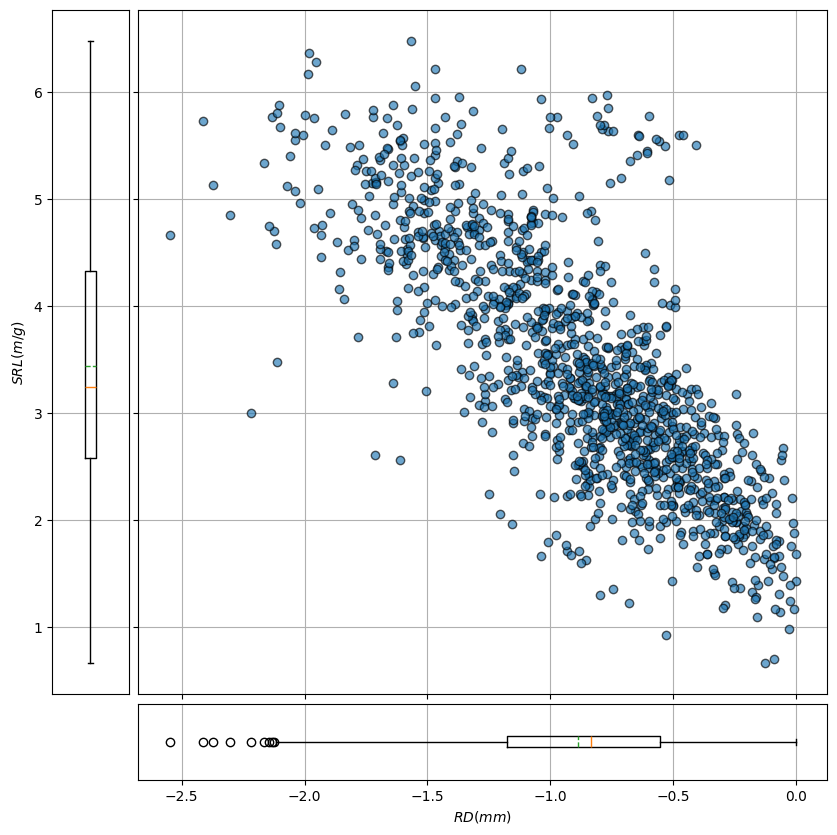

In [74]:
# species with no root order data whatsoever

# rd_qntls = np.quantile(a=collab_fineroots.query(r"F00056.isna()").F00679, q=(.25, .5, .75)) # RD quantiles
# srl_qntls = np.quantile(a=collab_fineroots.query(r"F00056.isna()").F00727, q=(.25, .5, .75)) # SRL quantiles

fig = plt.figure()
fig.set_size_inches(10, 10)
gspec = fig.add_gridspec(nrows=2, ncols=2, hspace=0.025, wspace=0.025, width_ratios=(0.1, 0.9), height_ratios=(0.9, 0.1))


axes_b = fig.add_subplot(gspec[1, 1])
axes_b.boxplot(averaged_subset.F00679, showmeans=True, meanline=True, tick_labels=None, orientation="horizontal")
axes_b.set_xlabel(r"$RD(mm)$")
axes_b.grid()
axes_b.set_yticks([])

axes_l = fig.add_subplot(gspec[0, 0])
axes_l.boxplot(averaged_subset.F00727, showmeans=True, meanline=True, tick_labels=None)
axes_l.set_ylabel(r"$SRL(m/g)$")
axes_l.grid()
axes_l.set_xticks([])

axes = fig.add_subplot(gspec[0, 1], sharex=axes_b, sharey=axes_l)
axes.scatter(x=averaged_subset.F00679, y=averaged_subset.F00727, edgecolor="black", alpha=0.65)
axes.grid()
plt.setp(axes.get_xticklabels(), visible=False)
plt.setp(axes.get_yticklabels(), visible=False)
axes.set_axisbelow(True)

plt.show()

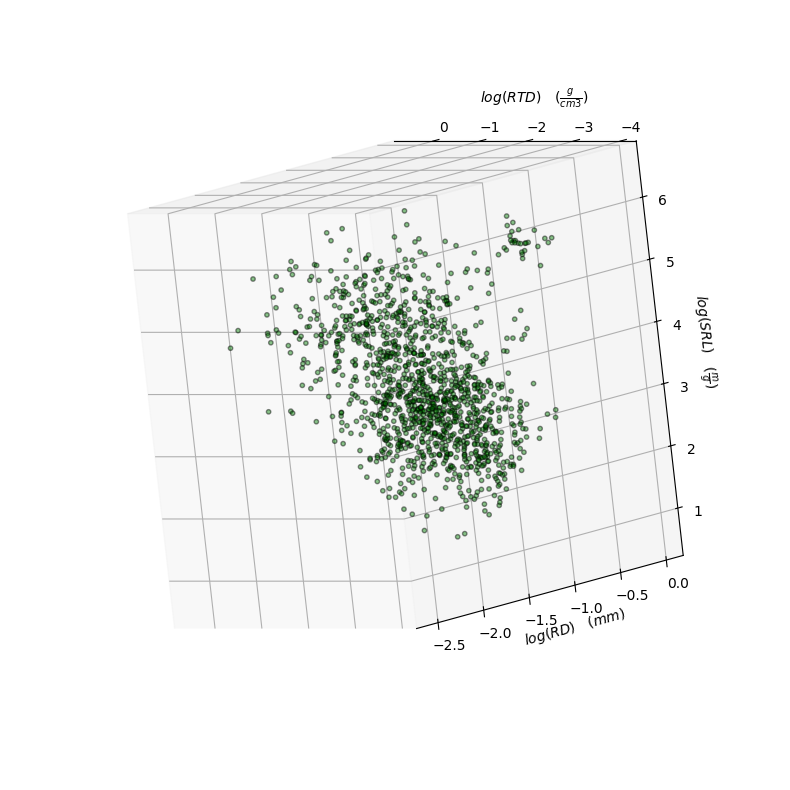

In [85]:
fig = plt.figure(figsize=(8, 8), layout="tight")
axes = fig.add_subplot(projection="3d", axisbelow=True)
axes.set_proj_type(proj_type="ortho")
axes.view_init(elev=40, azim=-10, roll=90)
axes.scatter(xs=averaged_subset.F00679, ys=averaged_subset.F00727, zs=averaged_subset.F00709, color="green", edgecolor="black", alpha=0.45, s=10)
axes.set_xlabel(r"$log(RD)\hspace{1}(mm)$")
axes.set_ylabel(r"$log(SRL)\hspace{1}(\frac{m}{g})$")
axes.set_zlabel(r"$log(RTD)\hspace{1}(\frac{g}{cm3})$")
axes.set_box_aspect(aspect=None, zoom=0.85) # zoom out to make the z label visible
plt.tight_layout()
plt.show()

In [83]:
# contains 1301 unique species
# RD, SRL & RTD values are species averaged
# all the continuous traits have been log transformed

continuous_traits = pd.merge(left=averaged_subset, left_on=BINOMINAL_NAME, right=subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates(subset=BINOMINAL_NAME).reset_index(drop=True),
                            right_on=BINOMINAL_NAME, how="left").loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS]
continuous_traits # good :)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
0,Abies,alba,Pinaceae,Pinales,-0.592397,3.466569,-1.409222
1,Abies,nephrolepis,Pinaceae,Pinales,-0.878915,3.297534,-1.274017
2,Acacia,auriculiformis,Fabaceae,Fabales,-0.711074,3.620422,-1.226446
3,Acacia,crassicarpa,Fabaceae,Fabales,-1.487530,4.684720,-1.021651
4,Acacia,mangium,Fabaceae,Fabales,-1.376146,4.597037,-1.237874
...,...,...,...,...,...,...,...
1296,Xanthophyllum,tenue,Polygalaceae,Fabales,-0.830687,3.228004,-1.250890
1297,Zabelia,biflora,Caprifoliaceae,Dipsacales,-0.636389,3.432278,-1.919393
1298,Zamia,lucayana,Zamiaceae,Cycadales,-1.116225,4.075373,-1.515606
1299,Zizia,aurea,Apiaceae,Apiales,-1.171183,4.605170,-2.040221


In [84]:
# this contains 1301 species averaged records => log transformed RD, SRL and RTD values and taxonomic information
continuous_traits.to_csv(r"../../data/chapter2/FRED/subsets/species_averaged_and_logged_continuous_traits_FRED4.csv", index=False)

### ___Mycorrhizal state filling___
-----------------------------

In [8]:
# 1301 unique taxa in FRED 4 RD <= 1.00 mm subset
taxa = pd.read_csv(r"../../data/chapter2/FRED/subsets/species_averaged_and_logged_continuous_traits_FRED4.csv").loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS]
taxa.loc[:, "binominal"] = taxa.loc[:, BINOMINAL_NAME].apply(' '.join, axis=1) # introduce a new column for binominal names

# mycorrhizal states in FRED 4.0 (from the respective data sources)
# this dataset is a hand cleaned version of the programatically cleaned and serialized .csv
# fred_states = pd.read_excel(r"../../data/chapter2/FRED/subsets/states.xlsx", sheet_name="FRED4")

# a trimmed .csv version of the FungalRoot species level dataset
fungalroot = pd.read_csv(r"../../data/chapter2/FungalRoot/fungalroot.csv", low_memory=False, header=0, skiprows=[1])
fungalroot.species = fungalroot.species.str.strip()

fungalroot_genus_state_recommendations = pd.read_excel(r"../../data/chapter2/FungalRoot/nph16569-sup-0002-tabless1-s4.xlsx", sheet_name="Table S2", skiprows=(0, 1), names=("genus", "state"))

maherali = pd.read_csv(r"../../data/chapter2/Maherali.etal.AmNat.Data.csv", names=("binominal", "state"), skiprows=1)
maherali.binominal = maherali.binominal.str.replace('_', ' ').str.strip()

wcvp_synonyms_lookup_table = pd.read_csv(r"../../data/chapter2/wcvp/synonyms.csv", low_memory=False)

#### ___1. Genus level mycorrhizal state recommendations from `FungalRoot`___

In [87]:
taxa.F01286.unique().isin(fungalroot_genus_state_recommendations.genus).mean() # that's good

np.float64(0.9654605263157895)

In [88]:
pd.merge(left=taxa, left_on="F01286", right=fungalroot_genus_state_recommendations, right_on="genus", how="left").drop(["genus"], axis=1)#.isna().mean()

,F01286,F01287,F01289,F01290,binominal,state
0,Abies,alba,Pinaceae,Pinales,Abies alba,EcM
1,Abies,nephrolepis,Pinaceae,Pinales,Abies nephrolepis,EcM
2,Acacia,auriculiformis,Fabaceae,Fabales,Acacia auriculiformis,EcM-AM
3,Acacia,crassicarpa,Fabaceae,Fabales,Acacia crassicarpa,EcM-AM
4,Acacia,mangium,Fabaceae,Fabales,Acacia mangium,EcM-AM
...,...,...,...,...,...,...
1296,Xanthophyllum,tenue,Polygalaceae,Fabales,Xanthophyllum tenue,AM
1297,Zabelia,biflora,Caprifoliaceae,Dipsacales,Zabelia biflora,AM
1298,Zamia,lucayana,Zamiaceae,Cycadales,Zamia lucayana,AM
1299,Zizia,aurea,Apiaceae,Apiales,Zizia aurea,AM


In [89]:
pd.merge(left=taxa, left_on="F01286", right=fungalroot_genus_state_recommendations, right_on="genus", how="left").drop(["genus"], axis=1)#.isna().mean()

,F01286,F01287,F01289,F01290,binominal,state
0,Abies,alba,Pinaceae,Pinales,Abies alba,EcM
1,Abies,nephrolepis,Pinaceae,Pinales,Abies nephrolepis,EcM
2,Acacia,auriculiformis,Fabaceae,Fabales,Acacia auriculiformis,EcM-AM
3,Acacia,crassicarpa,Fabaceae,Fabales,Acacia crassicarpa,EcM-AM
4,Acacia,mangium,Fabaceae,Fabales,Acacia mangium,EcM-AM
...,...,...,...,...,...,...
1296,Xanthophyllum,tenue,Polygalaceae,Fabales,Xanthophyllum tenue,AM
1297,Zabelia,biflora,Caprifoliaceae,Dipsacales,Zabelia biflora,AM
1298,Zamia,lucayana,Zamiaceae,Cycadales,Zamia lucayana,AM
1299,Zizia,aurea,Apiaceae,Apiales,Zizia aurea,AM


In [90]:
subset_genus_level = pd.merge(left=taxa, left_on="F01286", right=fungalroot_genus_state_recommendations, right_on="genus", how="left").drop(["genus"], axis=1).\
            loc[:, ["binominal"] + PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["state"]]
subset_genus_level

,binominal,F01286,F01287,F01289,F01290,state
0,Abies alba,Abies,alba,Pinaceae,Pinales,EcM
1,Abies nephrolepis,Abies,nephrolepis,Pinaceae,Pinales,EcM
2,Acacia auriculiformis,Acacia,auriculiformis,Fabaceae,Fabales,EcM-AM
3,Acacia crassicarpa,Acacia,crassicarpa,Fabaceae,Fabales,EcM-AM
4,Acacia mangium,Acacia,mangium,Fabaceae,Fabales,EcM-AM
...,...,...,...,...,...,...
1296,Xanthophyllum tenue,Xanthophyllum,tenue,Polygalaceae,Fabales,AM
1297,Zabelia biflora,Zabelia,biflora,Caprifoliaceae,Dipsacales,AM
1298,Zamia lucayana,Zamia,lucayana,Zamiaceae,Cycadales,AM
1299,Zizia aurea,Zizia,aurea,Apiaceae,Apiales,AM


In [91]:
subset_genus_level.state.value_counts(dropna=False)

state
AM                                             1057
EcM                                             118
NM-AM                                            40
NaN                                              34
EcM-AM                                           20
NM                                               16
ErM                                               9
uncertain                                         5
species-specific: AM or rarely EcM-AM or AM       2
Name: count, dtype: int64

In [92]:
wcvp_synonyms_lookup_table.head()

,name,synonym
0,Caladenia minorata,Caladenia glossodia
1,Chiloglottis gunnii,Caladenia gunnii
2,Volkameria acerbiana,Clerodendrum acerbianum
3,Veronica sibthorpioides,Cochlidiosperma sibthorpioides
4,Veronica sibthorpioides,Veronica hederifolia subsp. sibthorpioides


In [ ]:
# the rationale for leveraging synonyms is when Metrosideros umbellata and Agalmanthus umbellata are homotypic synonyms and the genus
# Metrosideros is unavailable in the lookup table, we could look up genus Agalmanthus.

In [100]:
# check the synonyms lookup table so we could fill some more species

genus_level_state_missing_species = subset_genus_level.query(r"state.isna()").binominal.values
# our binominal names in FRED 4.0 subset could be in the name column or synonym column of the lookup table!!!!

wcvp_synonyms_lookup_table.query(r"name.isin(@genus_level_state_missing_species)") # that's interesting!!

,name,synonym
479,Heptapleurum heptaphyllum,Aralia heptaphylla
2573,Sciodaphyllum acuminatum,Brassaia acuminata
10338,Heptapleurum heptaphyllum,Sciodaphyllum heptaphyllum
11908,Wurfbainia villosa,Cardamomum villosum
12700,Sciodaphyllum acuminatum,Schefflera acuminata
12738,Heptapleurum heptaphyllum,Schefflera heptaphylla
14896,Wurfbainia villosa,Elettaria villosa
15808,Wurfbainia villosa,Zingiber villosum
20951,Leptobalanus longistylus,Licania longistyla
20970,Leptobalanus octandrus,Licania octandra


In [101]:
# binominal names in the synonym column
wcvp_synonyms_lookup_table.query(r"synonym.isin(@genus_level_state_missing_species)")

,name,synonym
30916,Lycopodium volubile,Pseudodiphasium volubile
50455,Blechnum discolor,Lomaria discolor
65897,Blechnum novae-zelandiae,Parablechnum novae-zelandiae
80586,Blechnum procerum,Parablechnum procerum


In [97]:
wcvp_synonyms_lookup_table.query(r"synonym.isin(@genus_level_state_missing_species)").rename({"synonym": "name", "name": "synonym"}, axis=1)

,synonym,name
30916,Lycopodium volubile,Pseudodiphasium volubile
50455,Blechnum discolor,Lomaria discolor
65897,Blechnum novae-zelandiae,Parablechnum novae-zelandiae
80586,Blechnum procerum,Parablechnum procerum


In [102]:
# with dicts; cannot have multiple identical keys

alternative_genus_names = np.unique([(name.split(' ')[0], syn.split(' ')[0]) for _, (name, syn) in wcvp_synonyms_lookup_table.query(r"name.isin(@genus_level_state_missing_species)").iterrows()], axis=0)

# the first genus name is what FRED 4.0 has and the second genus name is an accepted alternative
alternative_genus_names = np.concat([alternative_genus_names,
                                     # putting syn as the first element of the tuple here because that's what present in FRED 4.0
                                     np.unique([(syn.split(' ')[0], name.split(' ')[0]) for _, (name, syn) in wcvp_synonyms_lookup_table.query(r"synonym.isin(@genus_level_state_missing_species)").iterrows()], axis=0)])

alternative_genus_names

array([['Alseodaphnopsis', 'Alseodaphne'],
       ['Alseodaphnopsis', 'Cryptocarya'],
       ['Andesanthus', 'Chaetogastra'],
       ['Andesanthus', 'Pleroma'],
       ['Andesanthus', 'Rhexia'],
       ['Andesanthus', 'Tibouchina'],
       ['Callitropsis', 'Chamaecyparis'],
       ['Callitropsis', 'Cupressus'],
       ['Callitropsis', 'Xanthocyparis'],
       ['Didymocheton', 'Dysoxylum'],
       ['Didymocheton', 'Trichilia'],
       ['Heptapleurum', 'Ampelopsis'],
       ['Heptapleurum', 'Aralia'],
       ['Heptapleurum', 'Schefflera'],
       ['Heptapleurum', 'Sciodaphyllum'],
       ['Heptapleurum', 'Vitis'],
       ['Hesperostipa', 'Stipa'],
       ['Hymenopus', 'Licania'],
       ['Imbralyx', 'Fordia'],
       ['Imbralyx', 'Millettia'],
       ['Leptobalanus', 'Hirtella'],
       ['Leptobalanus', 'Licania'],
       ['Leptobalanus', 'Moquilea'],
       ['Pectinopitys', 'Nageia'],
       ['Pectinopitys', 'Podocarpus'],
       ['Pectinopitys', 'Prumnopitys'],
       ['Pectinopitys', 

In [103]:
subset_genus_level.query("state.isna()").F01286.unique() # need states for these 25 genera

<StringArray>
['Alseodaphnopsis',     'Andesanthus',    'Callitropsis',    'Didymocheton',
    'Heptapleurum',    'Hesperostipa',       'Hymenopus',        'Imbralyx',
    'Leptobalanus',         'Lomaria',    'Parablechnum',    'Pectinopitys',
      'Prasoxylon', 'Pseudodictamnus', 'Pseudodiphasium',     'Pterophylla',
        'Richetia',     'Rubroshorea',   'Sciodaphyllum',      'Tetrapilus',
      'Wurfbainia']
Length: 21, dtype: str

In [105]:
# fungalroot_genus_state_recommendations.loc[fungalroot_genus_state_recommendations.genus.isin(alternative_genus_names_all[:, 1]), :]

# now, we match the alternative genus names with the FungalRoot genus level recommendations dataset, drop alternative genera that do not have data in it
# and remove the duplicates

fungalroot_synonym_salvaged_genus_level = pd.merge(left=pd.DataFrame(alternative_genus_names, columns=("genus", "synonym")), left_on="synonym", right=fungalroot_genus_state_recommendations,
         right_on="genus", how="left", suffixes=('', "_FungalRoot")).dropna().drop_duplicates(subset=("genus", "state")).drop("genus_FungalRoot", axis=1)

fungalroot_synonym_salvaged_genus_level

,genus,synonym,state
0,Alseodaphnopsis,Alseodaphne,AM
3,Andesanthus,Pleroma,AM
6,Callitropsis,Chamaecyparis,AM
9,Didymocheton,Dysoxylum,AM
11,Heptapleurum,Ampelopsis,AM
16,Hesperostipa,Stipa,AM
17,Hymenopus,Licania,AM
18,Imbralyx,Fordia,AM
20,Leptobalanus,Hirtella,AM
23,Pectinopitys,Nageia,AM


In [106]:
# need to update the genus level FRED 4 subset based on this
for row in fungalroot_synonym_salvaged_genus_level.itertuples():
   subset_genus_level.loc[subset_genus_level.query(r"F01286==@row.genus").index, "state"] = row.state

In [107]:
subset_genus_level.state.isna().sum() # that's awesome :)

np.int64(0)

In [108]:
subset_genus_level.state.value_counts()

state
AM                                             1087
EcM                                             121
NM-AM                                            41
EcM-AM                                           20
NM                                               16
ErM                                               9
uncertain                                         5
species-specific: AM or rarely EcM-AM or AM       2
Name: count, dtype: int64

In [109]:
subset_genus_level

,binominal,F01286,F01287,F01289,F01290,state
0,Abies alba,Abies,alba,Pinaceae,Pinales,EcM
1,Abies nephrolepis,Abies,nephrolepis,Pinaceae,Pinales,EcM
2,Acacia auriculiformis,Acacia,auriculiformis,Fabaceae,Fabales,EcM-AM
3,Acacia crassicarpa,Acacia,crassicarpa,Fabaceae,Fabales,EcM-AM
4,Acacia mangium,Acacia,mangium,Fabaceae,Fabales,EcM-AM
...,...,...,...,...,...,...
1296,Xanthophyllum tenue,Xanthophyllum,tenue,Polygalaceae,Fabales,AM
1297,Zabelia biflora,Zabelia,biflora,Caprifoliaceae,Dipsacales,AM
1298,Zamia lucayana,Zamia,lucayana,Zamiaceae,Cycadales,AM
1299,Zizia aurea,Zizia,aurea,Apiaceae,Apiales,AM


In [110]:
# now, serialize that to a .csv file

subset_genus_level.loc[:, "state"] = subset_genus_level.state.replace({"EcM-AM": "EcMAM", "NM-AM": "NMAM"})
subset_genus_level.to_csv(r"../../data/chapter2/FRED/subsets/FRED4_FungalRoot_genus_level_recommendations.csv", index=False)

#### ___2. Species specific mycorrhizal states___

In [10]:
# create a synonyms lookup table for all the 1301 species we have in the FRED 4.0 subset

wcvp_synonyms_lookup_table.query(r"name.isin(@taxa.binominal)")

,name,synonym
116,Metrosideros umbellata,Agalmanthus umbellata
264,Inga ruiziana,Feuilleea ruiziana
479,Heptapleurum heptaphyllum,Aralia heptaphylla
603,Galium aparine,Asterophyllum aparine
693,Syzygium acuminatissimum,Acmena acuminatissima
...,...,...
280952,Pappobolus microphyllus,Helianthus microphyllus
280966,Helianthus praecox,Helianthus debilis subsp. praecox
280967,Helianthus praecox,Helianthus cucumerifolius var. praecox
280969,Helianthus radula,Helianthus atrorubens subsp. radula


In [11]:
wcvp_synonyms_lookup_table.query(r"synonym.isin(@taxa.binominal)")

,name,synonym
2485,Ragala sanguinolenta,Chrysophyllum sanguinolentum
30916,Lycopodium volubile,Pseudodiphasium volubile
50455,Blechnum discolor,Lomaria discolor
50654,Onoclea struthiopteris,Matteuccia struthiopteris
53136,Camphora officinarum,Cinnamomum camphora
53148,Camphora micrantha,Cinnamomum micranthum
53152,Camphora parthenoxylon,Cinnamomum parthenoxylon
65897,Blechnum novae-zelandiae,Parablechnum novae-zelandiae
75193,Camphora glandulifera,Cinnamomum glanduliferum
80586,Blechnum procerum,Parablechnum procerum


In [17]:
# the column name is the binominal name FRED 4.0 uses

taxa_synonyms = pd.concat([wcvp_synonyms_lookup_table.query(r"name.isin(@taxa.binominal)"),
            wcvp_synonyms_lookup_table.query(r"synonym.isin(@taxa.binominal)").rename({"name": "synonym", "synonym": "name"}, axis=1)]).reset_index(drop=True)
taxa_synonyms

,name,synonym
0,Metrosideros umbellata,Agalmanthus umbellata
1,Inga ruiziana,Feuilleea ruiziana
2,Heptapleurum heptaphyllum,Aralia heptaphylla
3,Galium aparine,Asterophyllum aparine
4,Syzygium acuminatissimum,Acmena acuminatissima
...,...,...
1763,Morus insignis,Paratrophis insignis
1764,Trymatococcus amazonicus,Brosimum amazonicum
1765,Glochidion eriocarpum,Phyllanthus eriocarpus
1766,Chrysopsis villosa,Heterotheca villosa


In [27]:
# the problem with this is that FRED 4.0 only uses simple binominal names, so having varieties and subspecies in synonyms will likely reduce 
# our chances at finding synonym matches

taxa_synonyms.loc[taxa_synonyms.synonym.str.split().apply(len) > 2, :]

,name,synonym
9,Viola adunca,Viola canina var. adunca
11,Castanopsis echinocarpa,Castanopsis tribuloides var. echinocarpa
35,Malus baccata,Malus microcarpa baccata
40,Inga marginata,Inga fagifolia var. marginata
57,Populus tremuloides,Populus tremula subsp. tremuloides
...,...,...
1739,Helianthus heterophyllus,Helianthus atrorubens subsp. heterophyllus
1742,Helianthus praecox,Helianthus debilis subsp. praecox
1743,Helianthus praecox,Helianthus cucumerifolius var. praecox
1744,Helianthus radula,Helianthus atrorubens subsp. radula


In [35]:
# consider the synonyms Meriania franciscana and Meriania macrophylla subsp. franciscana
# here we transform Meriania macrophylla subsp. franciscana into just Meriania macrophylla so we get to find species level mycorrhizal state matches

#---------------------------------------------------------------------------------------------------------------------
# THIS IS DONE ASSUMING THERE WILL NOT BE ANY VARIETY OR SUBSPECIES LEVEL DIFFERENCES IN MYCORRHIZAL STATES
# I.E. WE ASSUME IF Helianthus atrorubens subsp. radula IS NM, ALL Helianthus atrorubens ARE NM!!!!
#---------------------------------------------------------------------------------------------------------------------

# gs here stands for genus species
taxa_synonyms.loc[:, "synonym_gs"] = taxa_synonyms.synonym.str.split().apply(lambda _list: _list[0] + ' ' + _list[1])
taxa_synonyms

,name,synonym,synonym_gs
0,Metrosideros umbellata,Agalmanthus umbellata,Agalmanthus umbellata
1,Inga ruiziana,Feuilleea ruiziana,Feuilleea ruiziana
2,Heptapleurum heptaphyllum,Aralia heptaphylla,Aralia heptaphylla
3,Galium aparine,Asterophyllum aparine,Asterophyllum aparine
4,Syzygium acuminatissimum,Acmena acuminatissima,Acmena acuminatissima
...,...,...,...
1763,Morus insignis,Paratrophis insignis,Paratrophis insignis
1764,Trymatococcus amazonicus,Brosimum amazonicum,Brosimum amazonicum
1765,Glochidion eriocarpum,Phyllanthus eriocarpus,Phyllanthus eriocarpus
1766,Chrysopsis villosa,Heterotheca villosa,Heterotheca villosa


In [36]:
taxa_synonyms.loc[taxa_synonyms.synonym.str.split().apply(len) > 2, :]

,name,synonym,synonym_gs
9,Viola adunca,Viola canina var. adunca,Viola canina
11,Castanopsis echinocarpa,Castanopsis tribuloides var. echinocarpa,Castanopsis tribuloides
35,Malus baccata,Malus microcarpa baccata,Malus microcarpa
40,Inga marginata,Inga fagifolia var. marginata,Inga fagifolia
57,Populus tremuloides,Populus tremula subsp. tremuloides,Populus tremula
...,...,...,...
1739,Helianthus heterophyllus,Helianthus atrorubens subsp. heterophyllus,Helianthus atrorubens
1742,Helianthus praecox,Helianthus debilis subsp. praecox,Helianthus debilis
1743,Helianthus praecox,Helianthus cucumerifolius var. praecox,Helianthus cucumerifolius
1744,Helianthus radula,Helianthus atrorubens subsp. radula,Helianthus atrorubens


In [ ]:
#------------------------------------------
# MYCORRHIZAL STATE HARVEST FROM FRED 4.0
#------------------------------------------

In [40]:
# consider only the species FRED 4.0 has mycorrhizal state info for doing this here so we can just load in the manually cleaned.csv into the state filling section
# we are using the whole FRED 4.0 dataset to look up mycorrhizal states, not just our subset!!!!

fred_states = fred.loc[:, BINOMINAL_NAME + ["F00645"]].dropna().drop_duplicates().sort_values(by=BINOMINAL_NAME).reset_index(drop=True)
fred_states = fred_states.apply(lambda col: col.str.strip(), axis=1)
fred_states.insert(loc=0, column="binominal", value=fred_states.F01286 + ' ' + fred_states.F01287)

# HERE WE NEED TO REDO THE TAXONOMIC CORRECTIONS WE DID TO BINOMINAL NAMES IN THE 1301 SPECIES SUBSET OF FRED 4.0!!!!

fred_states.loc[fred_states.query(r"F01286=='Helesia' and F01287=='tetraptera'").index, "F01286"] = "Halesia"
fred_states.loc[fred_states.query(r"F01286=='Austroblechnum' and F01287=='lanceolatum'").index, "F01286"] = "Blechnum"
fred_states.loc[fred_states.query(r"F01286=='Austroblechnum' and F01287=='lanceolatum'").index, "F01287"] = "chambersii"
fred_states.loc[fred_states.query(r"F01286=='Cranfillia' and F01287=='fluviatilis'").index, "F01286"] = "Blechnum"
fred_states.loc[fred_states.query(r"F01286=='Cranfillia' and F01287=='fluviatilis'").index, "F01287"] = "fluviatile"
fred_states.loc[fred_states.query(r"F01286=='Veronia' and F01287=='fasciculata'").index, "F01286"] = "Vernonia"

MYCORRHIZAL_STATE_REPLACEMENTS = { # mycorrhizal state encoding replacements
     "EM": "EcM",
     "AM + EM": "EcMAM",
     "AM + NM": "NMAM"
}

# drop the rows if F00645 is just "mycorrhizal" or any other useless stuff
fred_states = fred_states.query(r"not F00645.isin(['mycorrhizal', 'DS', 'EeM'])") 
fred_states.loc[:, "F00645"] = fred_states.F00645.replace(MYCORRHIZAL_STATE_REPLACEMENTS) # this contains many species we do not have continuous traits for.....

In [84]:
fred_states.query(r"binominal.isin(@taxa.binominal)").drop_duplicates(subset=("binominal", "F00645")) # that's great

,binominal,F01286,F01287,F00645
0,Abies alba,Abies,alba,EcM
12,Abies nephrolepis,Abies,nephrolepis,EcM
22,Acacia auriculiformis,Acacia,auriculiformis,AM
23,Acacia crassicarpa,Acacia,crassicarpa,EcMAM
25,Acacia mangium,Acacia,mangium,EcMAM
...,...,...,...,...
3342,Wurfbainia villosa,Wurfbainia,villosa,AM
3344,Xanthophyllum tenue,Xanthophyllum,tenue,AM
3346,Zabelia biflora,Zabelia,biflora,AM
3347,Zamia lucayana,Zamia,lucayana,AM


In [65]:
# now, leverage synonyms when the original name is unavailable

# taxa.query(r"not binominal.isin(@fred_states.binominal)")
state_needed_species = np.setdiff1d(taxa.binominal, fred_states.binominal)
state_needed_species[:10]

array(['Acer laurinum', 'Actinodaphne henryi', 'Afrocarpus falcatus',
       'Agastache foeniculum', 'Aglaia exstipulata',
       'Aglaia odoratissima', 'Agrostis scabra', 'Ailanthus fordii',
       'Aiouea montana', 'Allium textile'], dtype=object)

In [67]:
taxa_synonyms.query(r"name.isin(@state_needed_species)")

,name,synonym,synonym_gs
9,Viola adunca,Viola canina var. adunca,Viola canina
10,Weinmannia fagaroides,Windmannia fagaroides,Windmannia fagaroides
13,Weinmannia ovata,Windmannia ovata,Windmannia ovata
14,Weinmannia elliptica,Windmannia elliptica,Windmannia elliptica
15,Withania frutescens,Physalis frutescens,Physalis frutescens
...,...,...,...
1762,Coreopsis palmata,Anacis palmata,Anacis palmata
1763,Morus insignis,Paratrophis insignis,Paratrophis insignis
1765,Glochidion eriocarpum,Phyllanthus eriocarpus,Phyllanthus eriocarpus
1766,Chrysopsis villosa,Heterotheca villosa,Heterotheca villosa


In [76]:
# use the subset of only synonyms of species we don't have states for
pd.merge(left=fred_states, left_on="binominal", right=taxa_synonyms.query(r"name.isin(@state_needed_species)"), right_on="synonym_gs", how="inner")

,binominal,F01286,F01287,F00645,name,synonym,synonym_gs
0,Antennaria dioica,Antennaria,dioica,AM,Antennaria parvifolia,Antennaria dioica var. parvifolia,Antennaria dioica
1,Artemisia vulgaris,Artemisia,vulgaris,AM,Artemisia ludoviciana,Artemisia vulgaris var. ludoviciana,Artemisia vulgaris
2,Artemisia vulgaris,Artemisia,vulgaris,AM,Artemisia ludoviciana,Artemisia vulgaris subsp. ludoviciana,Artemisia vulgaris
3,Carex supina,Carex,supina,NMAM,Carex korshinskyi,Carex supina var. korshinskyi,Carex supina
4,Carex supina,Carex,supina,NMAM,Carex korshinskyi,Carex supina subsp. korshinskyi,Carex supina
5,Carex supina,Carex,supina,NM,Carex korshinskyi,Carex supina var. korshinskyi,Carex supina
6,Carex supina,Carex,supina,NM,Carex korshinskyi,Carex supina subsp. korshinskyi,Carex supina
7,Celtis sinensis,Celtis,sinensis,AM,Celtis tetrandra,Celtis sinensis var. tetrandra,Celtis sinensis
8,Fraxinus americana,Fraxinus,americana,AM,Fraxinus nigra,Fraxinus americana var. nigra,Fraxinus americana
9,Linum perenne,Linum,perenne,AM,Linum lewisii,Linum perenne subsp. lewisii,Linum perenne


In [88]:
# here the name colum contains the binomianl names we have continuous traits for in the FRED 4.0 subset!!!

pd.merge(left=fred_states, left_on="binominal", right=taxa_synonyms.query(r"name.isin(@state_needed_species)"), right_on="synonym_gs", how="inner").drop_duplicates(subset=("name", "F00645"))

,binominal,F01286,F01287,F00645,name,synonym,synonym_gs
0,Antennaria dioica,Antennaria,dioica,AM,Antennaria parvifolia,Antennaria dioica var. parvifolia,Antennaria dioica
1,Artemisia vulgaris,Artemisia,vulgaris,AM,Artemisia ludoviciana,Artemisia vulgaris var. ludoviciana,Artemisia vulgaris
3,Carex supina,Carex,supina,NMAM,Carex korshinskyi,Carex supina var. korshinskyi,Carex supina
5,Carex supina,Carex,supina,NM,Carex korshinskyi,Carex supina var. korshinskyi,Carex supina
7,Celtis sinensis,Celtis,sinensis,AM,Celtis tetrandra,Celtis sinensis var. tetrandra,Celtis sinensis
8,Fraxinus americana,Fraxinus,americana,AM,Fraxinus nigra,Fraxinus americana var. nigra,Fraxinus americana
9,Linum perenne,Linum,perenne,AM,Linum lewisii,Linum perenne subsp. lewisii,Linum perenne
11,Litsea baviensis,Litsea,baviensis,AM,Litsea szemaois,Litsea baviensis var. szemaois,Litsea baviensis
12,Potentilla verna,Potentilla,verna,AM,Potentilla pusilla,Potentilla verna var. pusilla,Potentilla verna
14,Quercus rubra,Quercus,rubra,EcM,Quercus palustris,Quercus rubra var. palustris,Quercus rubra


In [96]:
# now combine this with the species FRED already had state info for (for original names)

fred_states_final = pd.concat([fred_states.query(r"binominal.isin(@taxa.binominal)").loc[:, ("binominal", "F00645")].drop_duplicates(), # states fetched using the original names
            pd.merge(left=fred_states, left_on="binominal", right=taxa_synonyms.query(r"name.isin(@state_needed_species)"), right_on="synonym_gs", how="inner").loc[:, ["name", "F00645"]].drop_duplicates().rename({"name": "binominal"}, axis=1)] # states fetched using synonyms
).drop_duplicates().reset_index(drop=True)

fred_states_final

,binominal,F00645
0,Abies alba,EcM
1,Abies nephrolepis,EcM
2,Acacia auriculiformis,AM
3,Acacia crassicarpa,EcMAM
4,Acacia mangium,EcMAM
...,...,...
930,Quercus palustris,NM
931,Tragopogon dubius,AM
932,Trifolium purpureum,AM
933,Viola adunca,AM


In [97]:
fred_states_final.to_csv(r"../../data/chapter2/FRED/subsets/states_FRED4.csv", index=False) # this will need a little manual cleanup

In [100]:
#----------------------
# reusing the serialized states_FRED4.csv dataset instead of redoing all the wranging every time

state_needed_species = np.setdiff1d(taxa.binominal, pd.read_csv(r"../../data/chapter2/FRED/subsets/states_FRED4.csv").binominal.unique())
state_needed_species.size

430

In [102]:
#------------------------------------------------------
# MYCORRHIZAL STATE HARVEST FROM Maherali et al. 2016
#-----------------------------------------------------

In [106]:
maherali.query(r"binominal.isin(@state_needed_species)")

,binominal,state
102,Agrostis scabra,AM
164,Ambrosia artemisiifolia,AM
187,Andropogon gerardii,AM
209,Anthyllis cytisoides,AM
230,Arbutus unedo,EM
269,Asclepias incarnata,AM
270,Asclepias syriaca,AM
271,Asclepias tuberosa,AM
326,Baptisia alba,AM
350,Berteroa incana,NM


In [112]:
# for the state needed species not found in Maherali 2016, try leveraging their synonyms

taxa_synonyms.loc[taxa_synonyms.name.isin(np.setdiff1d(state_needed_species, maherali.query(r"binominal.isin(@state_needed_species)").binominal)), :]

,name,synonym,synonym_gs
10,Weinmannia fagaroides,Windmannia fagaroides,Windmannia fagaroides
13,Weinmannia ovata,Windmannia ovata,Windmannia ovata
14,Weinmannia elliptica,Windmannia elliptica,Windmannia elliptica
15,Withania frutescens,Physalis frutescens,Physalis frutescens
20,Hedeoma hispida,Cunila hispida,Cunila hispida
...,...,...,...
1762,Coreopsis palmata,Anacis palmata,Anacis palmata
1763,Morus insignis,Paratrophis insignis,Paratrophis insignis
1765,Glochidion eriocarpum,Phyllanthus eriocarpus,Phyllanthus eriocarpus
1766,Chrysopsis villosa,Heterotheca villosa,Heterotheca villosa


In [113]:
pd.merge(left=maherali, left_on="binominal", right=taxa_synonyms.loc[taxa_synonyms.name.isin(np.setdiff1d(state_needed_species, maherali.query(r"binominal.isin(@state_needed_species)").binominal)), :],
         right_on="synonym_gs", how="inner")

,binominal,state,name,synonym,synonym_gs
0,Anthyllis cytisoides,AM,Anthyllis terniflora,Anthyllis cytisoides subsp. terniflora,Anthyllis cytisoides
1,Armeria maritima,AMNM,Armeria velutina,Armeria maritima subsp. velutina,Armeria maritima
2,Arnica montana,AM,Arnica fulgens,Arnica montana var. fulgens,Arnica montana
3,Helianthus annuus,AM,Helianthus niveus,Helianthus annuus var. niveus,Helianthus annuus
4,Helianthus annuus,AM,Helianthus argophyllus,Helianthus annuus var. argophyllus,Helianthus annuus
5,Helianthus annuus,AM,Helianthus petiolaris,Helianthus annuus subsp. petiolaris,Helianthus annuus
6,Helianthus annuus,AM,Helianthus debilis,Helianthus annuus var. debilis,Helianthus annuus
7,Shorea leprosula,EM,Rubroshorea leprosula,Shorea leprosula,Shorea leprosula
8,Thymus vulgaris,AM,Thymus hyemalis,Thymus vulgaris var. hyemalis,Thymus vulgaris


In [116]:
pd.merge(left=maherali, left_on="binominal", right=taxa_synonyms.loc[taxa_synonyms.name.isin(np.setdiff1d(state_needed_species, maherali.query(r"binominal.isin(@state_needed_species)").binominal)), :],
         right_on="synonym_gs", how="inner").loc[:, ("name", "state")]

,name,state
0,Anthyllis terniflora,AM
1,Armeria velutina,AMNM
2,Arnica fulgens,AM
3,Helianthus niveus,AM
4,Helianthus argophyllus,AM
5,Helianthus petiolaris,AM
6,Helianthus debilis,AM
7,Rubroshorea leprosula,EM
8,Thymus hyemalis,AM


In [120]:
maherali_final =  pd.concat([pd.merge(left=maherali, left_on="binominal", right=taxa_synonyms.loc[taxa_synonyms.name.isin(np.setdiff1d(state_needed_species, maherali.query(r"binominal.isin(@state_needed_species)").binominal)), :],
         right_on="synonym_gs", how="inner").loc[:, ("name", "state")].rename({"name": "binominal"}, axis=1), # states salvaged leveraging synonyms
           maherali.query(r"binominal.isin(@state_needed_species)")] # states found using the original names
).drop_duplicates().reset_index(drop=True)
maherali_final

,binominal,state
0,Anthyllis terniflora,AM
1,Armeria velutina,AMNM
2,Arnica fulgens,AM
3,Helianthus niveus,AM
4,Helianthus argophyllus,AM
...,...,...
64,Thymus mastichina,AM
65,Ulex parviflorus,AM
66,Verbena hastata,AM
67,Vernonia fasciculata,AM


In [121]:
maherali_final.to_csv(r"../../data/chapter2/FRED/subsets/states_Maherali_2016.csv", index=False)

In [ ]:
# reusing the serialized datset

maherali_final = pd.read_csv(r"../../data/chapter2/FRED/subsets/states_Maherali_2016.csv")

In [127]:
# update the state needed species

state_needed_species = np.setdiff1d(state_needed_species, maherali_final.binominal)
state_needed_species

array(['Acer laurinum', 'Actinodaphne henryi', 'Afrocarpus falcatus',
       'Agastache foeniculum', 'Aglaia exstipulata',
       'Aglaia odoratissima', 'Ailanthus fordii', 'Aiouea montana',
       'Allium textile', 'Allophylus abyssinicus',
       'Alseodaphnopsis andersonii', 'Amelanchier alnifolia',
       'Anaxagorea javanica', 'Andesanthus lepidotus',
       'Androsace occidentalis', 'Anemone cylindrica', 'Aniba coto',
       'Aniba muca', 'Antennaria neglecta', 'Antiaris toxicaria',
       'Apodytes dimidiata', 'Aporosa subcaudata', 'Ardisia quinquegona',
       'Arnica sororia', 'Artemisia barrelieri', 'Artemisia cana',
       'Artocarpus lakoocha', 'Aster lanceolatus',
       'Astragalus aboriginum', 'Astragalus agrestis',
       'Astragalus bisulcatus', 'Astragalus canadensis',
       'Astragalus scaberrimus', 'Atractylis humilis',
       'Baccaurea ramiflora', 'Barringtonia fusicarpa',
       'Bathysa australis', 'Beilschmiedia purpurascens',
       'Bituminaria bituminosa', 

In [128]:
state_needed_species.size

361

In [129]:
#-----------------------------------------------
# MYCORRHIZAL STATE HARVEST FROM FungalRoot
#-----------------------------------------------

In [135]:
fungalroot.query(r"species.isin(@state_needed_species)").loc[:, ["species", "mycorrhiza type"]].drop_duplicates()

,species,mycorrhiza type
2578,Erica arborea,ErM
3640,Juniperus phoenicea,AM; others not addressed
7518,Astragalus scaberrimus,AM; others not addressed
7631,Sextonia rubra,AM; others not addressed
7642,Protium sagotianum,AM; others not addressed
...,...,...
33875,Sphaeralcea coccinea,AM; no others
33877,Phlox hoodii,AM; no others
34266,Symphyotrichum puniceum,AM; no others
34318,Zizia aurea,AM; no others


In [143]:
# okay, try leveraging synonyms

taxa_synonyms.loc[taxa_synonyms.name.isin(np.setdiff1d(state_needed_species, fungalroot.query(r"species.isin(@state_needed_species)").species.unique())), :]

,name,synonym,synonym_gs
10,Weinmannia fagaroides,Windmannia fagaroides,Windmannia fagaroides
13,Weinmannia ovata,Windmannia ovata,Windmannia ovata
14,Weinmannia elliptica,Windmannia elliptica,Windmannia elliptica
15,Withania frutescens,Physalis frutescens,Physalis frutescens
20,Hedeoma hispida,Cunila hispida,Cunila hispida
...,...,...,...
1760,Ocotea infrafoveolata,Andea infrafoveolata,Andea infrafoveolata
1762,Coreopsis palmata,Anacis palmata,Anacis palmata
1763,Morus insignis,Paratrophis insignis,Paratrophis insignis
1765,Glochidion eriocarpum,Phyllanthus eriocarpus,Phyllanthus eriocarpus


In [144]:
pd.merge(left=taxa_synonyms.loc[taxa_synonyms.name.isin(np.setdiff1d(state_needed_species, fungalroot.query(r"species.isin(@state_needed_species)").species.unique())), :],
        left_on="synonym_gs", right=fungalroot.loc[:, ("species", "mycorrhiza type")], right_on="species", how="inner")

,name,synonym,synonym_gs,species,mycorrhiza type
0,Carex tibetikobresia,Kobresia capillifolia var. tibetica,Kobresia capillifolia,Kobresia capillifolia,EcM; others not addressed
1,Carex tibetikobresia,Kobresia capillifolia var. tibetica,Kobresia capillifolia,Kobresia capillifolia,non-mycorrhizal (checked for all types)
2,Amelanchier alnifolia,Amelanchier sanguinea var. alnifolia,Amelanchier sanguinea,Amelanchier sanguinea,AM; no others
3,Amelanchier alnifolia,Amelanchier canadensis var. alnifolia,Amelanchier canadensis,Amelanchier canadensis,EcM; others not addressed
4,Amelanchier alnifolia,Amelanchier canadensis var. alnifolia,Amelanchier canadensis,Amelanchier canadensis,AM; no others
5,Festuca hallii,Festuca altaica subsp. hallii,Festuca altaica,Festuca altaica,AM; no others
6,Festuca hallii,Festuca altaica subvar. hallii,Festuca altaica,Festuca altaica,AM; no others
7,Bituminaria bituminosa,Psoralea bituminosa,Psoralea bituminosa,Psoralea bituminosa,AM; no others
8,Imbralyx leptobotrys,Millettia leptobotrys,Millettia leptobotrys,Millettia leptobotrys,AM; others not addressed
9,Hesperostipa comata,Stipa comata,Stipa comata,Stipa comata,AM; others not addressed


In [147]:
pd.merge(left=taxa_synonyms.loc[taxa_synonyms.name.isin(np.setdiff1d(state_needed_species, fungalroot.query(r"species.isin(@state_needed_species)").species.unique())), :],
        left_on="synonym_gs", right=fungalroot.loc[:, ("species", "mycorrhiza type")], right_on="species", how="inner").loc[:, ("name", "mycorrhiza type")].drop_duplicates().rename({"name": "species"}, axis=1)

,species,mycorrhiza type
0,Carex tibetikobresia,EcM; others not addressed
1,Carex tibetikobresia,non-mycorrhizal (checked for all types)
2,Amelanchier alnifolia,AM; no others
3,Amelanchier alnifolia,EcM; others not addressed
5,Festuca hallii,AM; no others
7,Bituminaria bituminosa,AM; no others
8,Imbralyx leptobotrys,AM; others not addressed
9,Hesperostipa comata,AM; others not addressed
11,Hesperostipa comata,AM; no others
12,Chamaecrista fasciculata,AM; no others


In [151]:
fungalroot_final = pd.concat([
    # states fished out using synonyms
    pd.merge(left=taxa_synonyms.loc[taxa_synonyms.name.isin(np.setdiff1d(state_needed_species, fungalroot.query(r"species.isin(@state_needed_species)").species.unique())), :],
        left_on="synonym_gs", right=fungalroot.loc[:, ("species", "mycorrhiza type")], right_on="species", how="inner").loc[:, ("name", "mycorrhiza type")].drop_duplicates().rename({"name": "species"}, axis=1),
    # states found using the original names in FRED 4.0
    fungalroot.query(r"species.isin(@state_needed_species)").loc[:, ["species", "mycorrhiza type"]].drop_duplicates()
]).reset_index(drop=True).drop_duplicates()

fungalroot_final

,species,mycorrhiza type
0,Carex tibetikobresia,EcM; others not addressed
1,Carex tibetikobresia,non-mycorrhizal (checked for all types)
2,Amelanchier alnifolia,AM; no others
3,Amelanchier alnifolia,EcM; others not addressed
4,Festuca hallii,AM; no others
...,...,...
120,Sphaeralcea coccinea,AM; no others
121,Phlox hoodii,AM; no others
122,Symphyotrichum puniceum,AM; no others
123,Zizia aurea,AM; no others


In [152]:
fungalroot_final.to_csv(r"../../data/chapter2/FRED/subsets/states_FungalRoot.csv", index=False)

In [155]:
# update the state needed species

state_needed_species = np.setdiff1d(state_needed_species, fungalroot_final.species)
state_needed_species.size

264

In [228]:
with open (file=r"../../data/chapter2/FRED/subsets/state_missing_species.json", mode="wt") as fp:
    json.dump(obj={
                    "species": [
                    {
                    "binominal": n,
                    "synonyms": list(taxa_synonyms.query(r"name==@n").synonym.values) if (n in taxa_synonyms.name.values) else None,
                    "F01286": taxa.loc[taxa.binominal==n, "F01286"].values[0],
                    "F01287": taxa.loc[taxa.binominal==n, "F01287"].values[0],
                    "F01289": taxa.loc[taxa.binominal==n, "F01289"].values[0],
                    "F01290": taxa.loc[taxa.binominal==n, "F01290"].values[0]
                    }
                    for n in state_needed_species
                    ]
                    }, indent=4, sort_keys=True, fp=fp)

In [231]:
[name for name in state_needed_species if name in taxa_synonyms.name.values][:10] # [ .... in taxa_synonyms.name] did not work???

['Agastache foeniculum',
 'Aglaia exstipulata',
 'Aiouea montana',
 'Allophylus abyssinicus',
 'Alseodaphnopsis andersonii',
 'Andesanthus lepidotus',
 'Androsace occidentalis',
 'Aniba coto',
 'Aniba muca',
 'Artemisia barrelieri']

In [223]:
np.intersect1d(state_needed_species, taxa_synonyms.name).size

140

In [235]:
"Weinmannia fagaroides" in taxa_synonyms.name, "Weinmannia fagaroides" in taxa_synonyms.name.values # that's strange???

(False, True)

In [5]:
#-----------------------------------------------------------------------------
# compile all the mycorrhizal state subsets that were cleaned up by hand
#-----------------------------------------------------------------------------

compiled_states = pd.concat([
            pd.read_excel(r"../../data/chapter2/FRED/subsets/species.xlsx", sheet_name="FRED4").loc[:, ["binominal", "reconciled_state"]].drop_duplicates().assign(source="FRED4"),
            pd.read_excel(r"../../data/chapter2/FRED/subsets/species.xlsx", sheet_name="FungalRoot").loc[:, ["binominal", "reconciled_state"]].drop_duplicates().assign(source="FungalRoot"),
            pd.read_excel(r"../../data/chapter2/FRED/subsets/species.xlsx", sheet_name="Maherali_2016").loc[:, ["binominal", "state"]].drop_duplicates().rename({"state": "reconciled_state"}, axis=1).assign(source="Maherali et. al. 2016")
]).reset_index(drop=True).sort_values(by="binominal")

compiled_states.loc[:, "reconciled_state"] = compiled_states.reconciled_state.replace({"EM": "EcM", "AMNM": "NMAM"})
assert compiled_states.binominal.unique().size == compiled_states.binominal.size, "cannot have duplicates here!"

compiled_states

,binominal,reconciled_state,source
0,Abies alba,EcM,FRED4
1,Abies nephrolepis,EcM,FRED4
2,Acacia auriculiformis,AM,FRED4
3,Acacia crassicarpa,EcMAM,FRED4
4,Acacia mangium,EcMAM,FRED4
...,...,...,...
854,Xanthophyllum tenue,AM,FRED4
855,Zabelia biflora,AM,FRED4
856,Zamia lucayana,AM,FRED4
967,Zizia aurea,AM,FungalRoot


In [6]:
compiled_states.reconciled_state.unique() # cool

<StringArray>
['EcM', 'AM', 'EcMAM', 'NMAM', 'NM', 'ErM']
Length: 6, dtype: str

In [10]:
compiled_states_extended = pd.merge(left=taxa, left_on="binominal", right=compiled_states, right_on="binominal", how="left").loc[:, ["binominal"] + PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["reconciled_state", "source"]]
compiled_states_extended

,binominal,F01286,F01287,F01289,F01290,reconciled_state,source
0,Abies alba,Abies,alba,Pinaceae,Pinales,EcM,FRED4
1,Abies nephrolepis,Abies,nephrolepis,Pinaceae,Pinales,EcM,FRED4
2,Acacia auriculiformis,Acacia,auriculiformis,Fabaceae,Fabales,AM,FRED4
3,Acacia crassicarpa,Acacia,crassicarpa,Fabaceae,Fabales,EcMAM,FRED4
4,Acacia mangium,Acacia,mangium,Fabaceae,Fabales,EcMAM,FRED4
...,...,...,...,...,...,...,...
1296,Xanthophyllum tenue,Xanthophyllum,tenue,Polygalaceae,Fabales,AM,FRED4
1297,Zabelia biflora,Zabelia,biflora,Caprifoliaceae,Dipsacales,AM,FRED4
1298,Zamia lucayana,Zamia,lucayana,Zamiaceae,Cycadales,AM,FRED4
1299,Zizia aurea,Zizia,aurea,Apiaceae,Apiales,AM,FungalRoot


In [11]:
synonyms = []

for sp in compiled_states_extended.binominal:
    _syns = wcvp_synonyms_lookup_table.loc[wcvp_synonyms_lookup_table.name==sp, "synonym"].values
    synonyms.append(list(_syns) if _syns.any() else np.nan) # if not empty append the synonyms else append a np.nan

compiled_states_extended.loc[:, "synonyms"] = pd.Series(synonyms)
compiled_states_extended

,binominal,F01286,F01287,F01289,F01290,reconciled_state,source,synonyms
0,Abies alba,Abies,alba,Pinaceae,Pinales,EcM,FRED4,"[Pinus alba, Pinus abies var. pectinata, Pinus..."
1,Abies nephrolepis,Abies,nephrolepis,Pinaceae,Pinales,EcM,FRED4,"[Abies veitchii var. nephrolepis, Abies sibiri..."
2,Acacia auriculiformis,Acacia,auriculiformis,Fabaceae,Fabales,AM,FRED4,[Racosperma auriculiforme]
3,Acacia crassicarpa,Acacia,crassicarpa,Fabaceae,Fabales,EcMAM,FRED4,[Racosperma crassicarpum]
4,Acacia mangium,Acacia,mangium,Fabaceae,Fabales,EcMAM,FRED4,[Racosperma mangium]
...,...,...,...,...,...,...,...,...
1296,Xanthophyllum tenue,Xanthophyllum,tenue,Polygalaceae,Fabales,AM,FRED4,NaN
1297,Zabelia biflora,Zabelia,biflora,Caprifoliaceae,Dipsacales,AM,FRED4,[Abelia biflora]
1298,Zamia lucayana,Zamia,lucayana,Zamiaceae,Cycadales,AM,FRED4,NaN
1299,Zizia aurea,Zizia,aurea,Apiaceae,Apiales,AM,FungalRoot,"[Smyrnium aureum, Sison aureum, Carum aureum, ..."


In [12]:
compiled_states_extended.to_csv(r"../../data/chapter2/FRED/subsets/species_hand_cleaned.csv", index=False)

### ___1. State revision___
------------------------

In [5]:
states = pd.read_csv(r"../../data/chapter2/FRED/subsets/species_hand_cleaned.csv")
states

,binominal,F01286,F01287,F01289,F01290,reconciled_state,synonyms
0,Abies alba,Abies,alba,Pinaceae,Pinales,EcM,"['Pinus alba', 'Pinus abies var. pectinata', '..."
1,Abies nephrolepis,Abies,nephrolepis,Pinaceae,Pinales,EcM,"['Abies veitchii var. nephrolepis', 'Abies sib..."
2,Acacia auriculiformis,Acacia,auriculiformis,Fabaceae,Fabales,AM,['Racosperma auriculiforme']
3,Acacia crassicarpa,Acacia,crassicarpa,Fabaceae,Fabales,EcMAM,['Racosperma crassicarpum']
4,Acacia mangium,Acacia,mangium,Fabaceae,Fabales,EcMAM,['Racosperma mangium']
...,...,...,...,...,...,...,...
1296,Xanthophyllum tenue,Xanthophyllum,tenue,Polygalaceae,Fabales,AM,NaN
1297,Zabelia biflora,Zabelia,biflora,Caprifoliaceae,Dipsacales,AM,['Abelia biflora']
1298,Zamia lucayana,Zamia,lucayana,Zamiaceae,Cycadales,AM,NaN
1299,Zizia aurea,Zizia,aurea,Apiaceae,Apiales,AM,"['Smyrnium aureum', 'Sison aureum', 'Carum aur..."


In [119]:
#--------------------------------------------------------------
# cross checking state conflicts after the first revision
#--------------------------------------------------------------

revision = pd.read_excel(r"../../data/chapter2/FRED/subsets/species.xlsx", sheet_name="combined")
revision.head()

,binominal,F01286,F01289,F01290_not_crosschecked,reconciled_state,source,state_revision_1,revision_1_source,state_revision_2,revision_2_source,synonyms
0,Abies alba,Abies,Pinaceae,Pinales,EcM,FRED4,EcM,NaN,EcM,NaN,"['Pinus alba', 'Pinus abies var. pectinata', '..."
1,Abies nephrolepis,Abies,Pinaceae,Pinales,EcM,FRED4,EcM,NaN,EcM,NaN,"['Abies veitchii var. nephrolepis', 'Abies sib..."
2,Acacia auriculiformis,Acacia,Fabaceae,Fabales,AM,FRED4,AM,NaN,EcMAM,"(Soudzilovskaia et al., 2020)",['Racosperma auriculiforme']
3,Acacia crassicarpa,Acacia,Fabaceae,Fabales,EcMAM,FRED4,EcMAM,NaN,EcMAM,NaN,['Racosperma crassicarpum']
4,Acacia mangium,Acacia,Fabaceae,Fabales,EcMAM,FRED4,EcMAM,NaN,EcMAM,NaN,['Racosperma mangium']


In [120]:
# see which families have multiple state encodings and what are they???
# and cross check that with Brundrett, M.C. and Tedersoo, L. (2018) ‘Evolutionary history of mycorrhizal symbioses and global host plant diversity’,
# New Phytologist, 220(4), pp. 1108–1115. Available at: https://doi.org/10.1111/nph.14976.

{fam: tuple(df.state_revision_1.unique()) for (fam, df) in revision.groupby("F01289", as_index=False) if df.state_revision_1.unique().size > 1}

{'Amaranthaceae': ('NMAM', 'AM'),
 'Annonaceae': ('AM', 'NM'),
 'Apocynaceae': ('AM', 'NMAM'),
 'Asparagaceae': ('AM', 'NMAM'),
 'Asteraceae': ('NMAM', 'AM', 'NM'),
 'Cannabaceae': ('AM', 'NM'),
 'Chloranthaceae': ('AM', 'NMAM'),
 'Cistaceae': ('EcM', 'AM', 'EcMAM'),
 'Cornaceae': ('AM', 'EcMAM'),
 'Cupressaceae': ('AM', 'NMAM'),
 'Cyperaceae': ('NM', 'NMAM', 'AM'),
 'Dryopteridaceae': ('NM', 'AM'),
 'Equisetaceae': ('NMAM', 'NM'),
 'Ericaceae': ('EcM', 'ErM'),
 'Fabaceae': ('AM', 'EcMAM', 'NMAM', 'NM'),
 'Fagaceae': ('EcM', 'AM', 'NMAM'),
 'Gleicheniaceae': ('AM', 'NM'),
 'Juglandaceae': ('EcM', 'AM'),
 'Lamiaceae': ('AM', 'NMAM'),
 'Lauraceae': ('AM', 'NM'),
 'Malvaceae': ('AM', 'EcM', 'EcMAM'),
 'Melastomataceae': ('AM', 'EcMAM'),
 'Moraceae': ('NMAM', 'AM'),
 'Myrtaceae': ('AM', 'EcMAM', 'EcM'),
 'Nothofagaceae': ('EcMAM', 'AM', 'EcM'),
 'Oleaceae': ('AM', 'EcMAM'),
 'Pinaceae': ('EcM', 'EcMAM'),
 'Plantaginaceae': ('AM', 'NMAM'),
 'Poaceae': ('AM', 'NMAM', 'EcMAM'),
 'Polygonaceae

In [96]:
# families that need to be hand reconciled ??.....

# Amaranthaceae - correct, has been cross checked with FungalRoot (Soudzilovskaia et al., 2020)
# Annonaceae - rectified using (Brundrett and Tedersoo, 2018)
# Apocynaceae - rectified using (Soudzilovskaia et al., 2020)
# Asparagaceae - rectified using (Soudzilovskaia et al., 2020)
# Asteraceae - rectified using (Soudzilovskaia et al., 2020) & (Brundrett and Tedersoo, 2018)
# Cannabaceae - rectified using (Brundrett and Tedersoo, 2018)
# Chloranthaceae - rectified using (Soudzilovskaia et al., 2020)
# Cistaceae - rectified using (Soudzilovskaia et al., 2020)
# Cornaceae - rectified using (Soudzilovskaia et al., 2020)
# Cupressaceae - rectified using (Soudzilovskaia et al., 2020)
# Cyperaceae - rectified using (Soudzilovskaia et al., 2020)
# Dryopteridaceae - rectified using (Soudzilovskaia et al., 2020)
# Equisetaceae - rectified using (Soudzilovskaia et al., 2020)
# Ericaceae - correct, has been cross checked with FungalRoot (Soudzilovskaia et al., 2020)
# Fabaceae - rectified using (Soudzilovskaia et al., 2020)
# Fagaceae - rectified using (Soudzilovskaia et al., 2020)
# Gleicheniaceae - rectified using (Soudzilovskaia et al., 2020)
# Juglandaceae - correct, has been cross checked with FungalRoot (Soudzilovskaia et al., 2020)
# Lamiaceae - correct, has been cross checked with (Soudzilovskaia et al., 2020) & (Brundrett and Tedersoo, 2018)
# Lauraceae - rectified using (Soudzilovskaia et al., 2020)
# Malvaceae - rectified using (Soudzilovskaia et al., 2020)
# Melastomataceae - rectified using (Soudzilovskaia et al., 2020)
# Moraceae - rectified using (Soudzilovskaia et al., 2020)
# Myrtaceae - rectified using (Soudzilovskaia et al., 2020)
# Nothofagaceae - rectified using (Soudzilovskaia et al., 2020)
# Oleaceae - rectified using (Soudzilovskaia et al., 2020)
# Pinaceae - rectified using (Soudzilovskaia et al., 2020)
# Plantaginaceae - rectified using (Soudzilovskaia et al., 2020)
# Poaceae - rectified using (Soudzilovskaia et al., 2020)
# Polygonaceae - rectified using (Soudzilovskaia et al., 2020)
# Primulaceae - rectified using (Soudzilovskaia et al., 2020)
# Proteaceae - rectified using (Soudzilovskaia et al., 2020)
# Ranunculaceae - rectified using (Soudzilovskaia et al., 2020)
# Rhamnaceae - rectified using (Soudzilovskaia et al., 2020)
# Rosaceae - rectified using (Brundrett and Tedersoo, 2018)
# Rubiaceae - rectified using (Soudzilovskaia et al., 2020)
# Salicaceae - rectified using (Brundrett and Tedersoo, 2018)
# Santalaceae - all good, has been cross checked with (Soudzilovskaia et al., 2020)
# Sapindaceae - rectified using (Brundrett and Tedersoo, 2018)
# Saxifragaceae - rectified using (Soudzilovskaia et al., 2020)
# Ulmaceae - rectified using (Brundrett and Tedersoo, 2018)

In [122]:
# cool :)
{fam: tuple(df.state_revision_2.unique()) for (fam, df) in revision.groupby("F01289", as_index=False) if df.state_revision_2.unique().size > 1}

{'Amaranthaceae': ('NMAM', 'AM'),
 'Aspleniaceae': ('NMAM', 'AM'),
 'Ericaceae': ('EcM', 'ErM'),
 'Fabaceae': ('EcMAM', 'AM', 'NM'),
 'Juglandaceae': ('EcM', 'AM'),
 'Lamiaceae': ('AM', 'NMAM'),
 'Lauraceae': ('AM', 'NMAM'),
 'Lecythidaceae': ('AM', 'NMAM'),
 'Malvaceae': ('AM', 'EcM'),
 'Myrtaceae': ('AM', 'EcMAM'),
 'Poaceae': ('AM', 'NMAM'),
 'Polygonaceae': ('EcM', 'NMAM'),
 'Ranunculaceae': ('AM', 'NMAM'),
 'Rubiaceae': ('AM', 'NMAM'),
 'Salicaceae': ('AM', 'EcMAM'),
 'Santalaceae': ('AM', 'NMAM'),
 'Urticaceae': ('NMAM', 'AM')}

In [123]:
# for families that only have one mycorrhizal state, cross check the states with FungalRoot genus level recommendations

one_state_fams = np.array([fam for (fam, df) in revision.groupby("F01289", as_index=False) if df.state_revision_1.unique().size == 1])
one_state_genera = revision.query(r"F01289.isin(@one_state_fams)").loc[:, ["F01286", "F01289", "state_revision_1", "state_revision_2"]].drop_duplicates()
one_state_genera

,F01286,F01289,state_revision_1,state_revision_2
24,Ackama,Cunoniaceae,AM,AM
25,Acronychia,Rutaceae,AM,AM
27,Actinidia,Actinidiaceae,AM,AM
30,Adiantum,Pteridaceae,AM,AM
35,Afrocarpus,Podocarpaceae,AM,AM
...,...,...,...,...
1293,Wurfbainia,Zingiberaceae,AM,AM
1295,Xanthophyllum,Polygalaceae,AM,AM
1297,Zabelia,Caprifoliaceae,AM,AM
1298,Zamia,Zamiaceae,AM,AM


In [124]:
fungalroot_genus_level_states = pd.read_excel(r"../../data/chapter2/FungalRoot/nph16569-sup-0002-tabless1-s4.xlsx", sheet_name="Table S2", skiprows=2).rename({"Genus": "genus", "Mycorrhizal type": "state"}, axis=1)
fungalroot_genus_level_states.loc[:, "state"] = fungalroot_genus_level_states.state.replace({"NM-AM": "NMAM"})

In [125]:
fungalroot_genus_level_states.state.unique()

<StringArray>
[                                         'OM',
                                          'AM',
                                          'NM',
                                         'EcM',
                                        'NMAM',
                                      'EcM-AM',
                                         'ErM',
                                   'uncertain',
         'species-specific EcM-AM or AM or NM',
 'species-specific: AM or rarely EcM-AM or AM',
                           'NM-AM, rarely EcM',
              'species-specific: EcM or NM-AM',
                                 'Thysanothus',
                                          'nM']
Length: 14, dtype: str

In [126]:
# seems doable :)

pd.merge(left=one_state_genera, left_on="F01286", right=fungalroot_genus_level_states, right_on="genus", how="left").query(r"state_revision_1!=state")

,F01286,F01289,state_revision_1,state_revision_2,genus,state
22,Apodytes,Metteniusaceae,NMAM,AM,Apodytes,AM
29,Sciodaphyllum,Araliaceae,AM,AM,NaN,NaN
30,Asplenium,Aspleniaceae,AM,NMAM,Asplenium,NMAM
41,Campanula,Campanulaceae,NMAM,AM,Campanula,AM
55,Cibotium,Cibotiaceae,NM,AM,Cibotium,AM
65,Corythophora,Lecythidaceae,AM,NMAM,Corythophora,NMAM
81,Didymocheton,Meliaceae,AM,AM,NaN,NaN
99,Richetia,Dipterocarpaceae,EcM,EcM,NaN,NaN
101,Rubroshorea,Dipterocarpaceae,EcM,EcM,NaN,NaN
111,Gnetum,Gnetaceae,AM,EcM,Gnetum,EcM


In [127]:
pd.merge(left=one_state_genera, left_on="F01286", right=fungalroot_genus_level_states, right_on="genus", how="left").query(r"state_revision_2!=state")

,F01286,F01289,state_revision_1,state_revision_2,genus,state
29,Sciodaphyllum,Araliaceae,AM,AM,NaN,NaN
81,Didymocheton,Meliaceae,AM,AM,NaN,NaN
99,Richetia,Dipterocarpaceae,EcM,EcM,NaN,NaN
101,Rubroshorea,Dipterocarpaceae,EcM,EcM,NaN,NaN
120,Heptapleurum,Araliaceae,AM,AM,NaN,NaN
121,Hymenopus,Chrysobalanaceae,AM,AM,NaN,NaN
130,Leptobalanus,Chrysobalanaceae,AM,AM,NaN,NaN
134,Lomaria,Blechnaceae,AM,AM,NaN,NaN
166,Parablechnum,Blechnaceae,AM,AM,NaN,NaN
169,Pectinopitys,Podocarpaceae,AM,AM,NaN,NaN


In [128]:
# reconcile these
# all of these have been corrected manually in state_revision_2

pd.merge(left=one_state_genera, left_on="F01286", right=fungalroot_genus_level_states, right_on="genus", how="left").query(r"state_revision_1!=state").dropna(subset="state")

,F01286,F01289,state_revision_1,state_revision_2,genus,state
22,Apodytes,Metteniusaceae,NMAM,AM,Apodytes,AM
30,Asplenium,Aspleniaceae,AM,NMAM,Asplenium,NMAM
41,Campanula,Campanulaceae,NMAM,AM,Campanula,AM
55,Cibotium,Cibotiaceae,NM,AM,Cibotium,AM
65,Corythophora,Lecythidaceae,AM,NMAM,Corythophora,NMAM
111,Gnetum,Gnetaceae,AM,EcM,Gnetum,EcM
162,Oreocnide,Urticaceae,AM,NMAM,Oreocnide,NMAM
163,Orthocarpus,Orobanchaceae,NMAM,NM,Orthocarpus,NM
203,Schoepfia,Schoepfiaceae,NM,AM,Schoepfia,AM
219,Thymelaea,Thymelaeaceae,NMAM,AM,Thymelaea,AM


In [129]:
# great :)
pd.merge(left=one_state_genera, left_on="F01286", right=fungalroot_genus_level_states, right_on="genus", how="left").query(r"state_revision_2!=state").dropna(subset="state")

,F01286,F01289,state_revision_1,state_revision_2,genus,state


In [130]:
# cross validate these at a higher taxonomic level
# these records are all correct :)

pd.merge(left=one_state_genera, left_on="F01286", right=fungalroot_genus_level_states, right_on="genus", how="left").query(r"state.isna()").sort_values(by="F01289")

,F01286,F01289,state_revision_1,state_revision_2,genus,state
29,Sciodaphyllum,Araliaceae,AM,AM,NaN,NaN
120,Heptapleurum,Araliaceae,AM,AM,NaN,NaN
134,Lomaria,Blechnaceae,AM,AM,NaN,NaN
166,Parablechnum,Blechnaceae,AM,AM,NaN,NaN
121,Hymenopus,Chrysobalanaceae,AM,AM,NaN,NaN
130,Leptobalanus,Chrysobalanaceae,AM,AM,NaN,NaN
193,Pterophylla,Cunoniaceae,AM,AM,NaN,NaN
99,Richetia,Dipterocarpaceae,EcM,EcM,NaN,NaN
101,Rubroshorea,Dipterocarpaceae,EcM,EcM,NaN,NaN
189,Pseudodiphasium,Lycopodiaceae,AM,AM,NaN,NaN


In [131]:
#---------
# tests
#---------

pd.merge(
    left=revision.query(r"F01289==''").loc[:, ["binominal", "F01286", "state_revision_1"]].drop_duplicates(subset=["F01286", "state_revision_1"]),
    left_on="F01286", right=fungalroot_genus_level_states, right_on="genus", how="left"
).drop("genus", axis=1).query(r"state_revision_1!=state")

,binominal,F01286,state_revision_1,state


## ___Final dataset___
--------------------------------

In [9]:
cont = pd.read_csv(r"../../data/chapter2/FRED/subsets/species_averaged_and_logged_continuous_traits_FRED4.csv").drop("F01290", axis=1)
cont

,F01286,F01287,F01289,F00679,F00727,F00709
0,Abies,alba,Pinaceae,-0.592397,3.466569,-1.409222
1,Abies,nephrolepis,Pinaceae,-0.878915,3.297534,-1.274017
2,Acacia,auriculiformis,Fabaceae,-0.711074,3.620422,-1.226446
3,Acacia,crassicarpa,Fabaceae,-1.487530,4.684720,-1.021651
4,Acacia,mangium,Fabaceae,-1.376146,4.597037,-1.237874
...,...,...,...,...,...,...
1296,Xanthophyllum,tenue,Polygalaceae,-0.830687,3.228004,-1.250890
1297,Zabelia,biflora,Caprifoliaceae,-0.636389,3.432278,-1.919393
1298,Zamia,lucayana,Zamiaceae,-1.116225,4.075373,-1.515606
1299,Zizia,aurea,Apiaceae,-1.171183,4.605170,-2.040221


In [11]:
cat = pd.read_excel(r"../../data/chapter2/FRED/subsets/species.xlsx", sheet_name="combined").drop("F01290_not_crosschecked", axis=1)
cat

,binominal,F01286,F01289,reconciled_state,source,state_revision_1,revision_1_source,state_revision_2,revision_2_source,synonyms
0,Abies alba,Abies,Pinaceae,EcM,FRED4,EcM,NaN,EcM,NaN,"['Pinus alba', 'Pinus abies var. pectinata', '..."
1,Abies nephrolepis,Abies,Pinaceae,EcM,FRED4,EcM,NaN,EcM,NaN,"['Abies veitchii var. nephrolepis', 'Abies sib..."
2,Acacia auriculiformis,Acacia,Fabaceae,AM,FRED4,AM,NaN,EcMAM,"(Soudzilovskaia et al., 2020)",['Racosperma auriculiforme']
3,Acacia crassicarpa,Acacia,Fabaceae,EcMAM,FRED4,EcMAM,NaN,EcMAM,NaN,['Racosperma crassicarpum']
4,Acacia mangium,Acacia,Fabaceae,EcMAM,FRED4,EcMAM,NaN,EcMAM,NaN,['Racosperma mangium']
...,...,...,...,...,...,...,...,...,...,...
1296,Xanthophyllum tenue,Xanthophyllum,Polygalaceae,AM,FRED4,AM,NaN,AM,NaN,NaN
1297,Zabelia biflora,Zabelia,Caprifoliaceae,AM,FRED4,AM,NaN,AM,NaN,['Abelia biflora']
1298,Zamia lucayana,Zamia,Zamiaceae,AM,FRED4,AM,NaN,AM,NaN,NaN
1299,Zizia aurea,Zizia,Apiaceae,AM,FungalRoot,AM,NaN,AM,NaN,"['Smyrnium aureum', 'Sison aureum', 'Carum aur..."


In [14]:
source = cat.loc[:, ["reconciled_state", "source", "state_revision_1", "revision_1_source", "state_revision_2", "revision_2_source"]]
source

,reconciled_state,source,state_revision_1,revision_1_source,state_revision_2,revision_2_source
0,EcM,FRED4,EcM,NaN,EcM,NaN
1,EcM,FRED4,EcM,NaN,EcM,NaN
2,AM,FRED4,AM,NaN,EcMAM,"(Soudzilovskaia et al., 2020)"
3,EcMAM,FRED4,EcMAM,NaN,EcMAM,NaN
4,EcMAM,FRED4,EcMAM,NaN,EcMAM,NaN
...,...,...,...,...,...,...
1296,AM,FRED4,AM,NaN,AM,NaN
1297,AM,FRED4,AM,NaN,AM,NaN
1298,AM,FRED4,AM,NaN,AM,NaN
1299,AM,FungalRoot,AM,NaN,AM,NaN


In [24]:
# to unify the sources the state info has come from; 
# first prioritize the revision 2 source, if that's empty, use revision 1 source
# if both of these are empty, use the original 'source' column

unified_sources = source.revision_2_source.fillna(source.revision_1_source).fillna(source.source)#.isna().sum()
unified_sources.value_counts()

revision_2_source
FRED4                             775
(Brundrett and Tedersoo, 2018)    240
(Soudzilovskaia et al., 2020)     110
FungalRoot                         76
Maherali et. al. 2016              62
Luke                               38
Name: count, dtype: int64

In [27]:
unified_sources = unified_sources.replace({"FungalRoot": "(Soudzilovskaia et al., 2020)", "Luke": "(Brundrett and Tedersoo, 2018)"})
unified_sources.value_counts()

revision_2_source
FRED4                             775
(Brundrett and Tedersoo, 2018)    278
(Soudzilovskaia et al., 2020)     186
Maherali et. al. 2016              62
Name: count, dtype: int64

In [37]:
cont.insert(loc=0, column="binominal", value=(cont.F01286 + ' ' + cont.F01287).str.strip())

In [33]:
cat.loc[:, ["binominal", "F01286", "F01289", "state_revision_2"]].assign(state_source=unified_sources)

,binominal,F01286,F01289,state_revision_2,state_source
0,Abies alba,Abies,Pinaceae,EcM,FRED4
1,Abies nephrolepis,Abies,Pinaceae,EcM,FRED4
2,Acacia auriculiformis,Acacia,Fabaceae,EcMAM,"(Soudzilovskaia et al., 2020)"
3,Acacia crassicarpa,Acacia,Fabaceae,EcMAM,FRED4
4,Acacia mangium,Acacia,Fabaceae,EcMAM,FRED4
...,...,...,...,...,...
1296,Xanthophyllum tenue,Xanthophyllum,Polygalaceae,AM,FRED4
1297,Zabelia biflora,Zabelia,Caprifoliaceae,AM,FRED4
1298,Zamia lucayana,Zamia,Zamiaceae,AM,FRED4
1299,Zizia aurea,Zizia,Apiaceae,AM,"(Soudzilovskaia et al., 2020)"


In [45]:
final = pd.merge(left=cat.loc[:, ["binominal", "F01286", "F01289", "state_revision_2", "synonyms"]].assign(state_source=unified_sources), left_on="binominal",
        right=cont.loc[:, CHOSEN_ROOT_TRAITS + ["binominal"]], right_on="binominal").rename({"state_revision_2": "state"}, axis=1)
final

,binominal,F01286,F01289,state,synonyms,state_source,F00679,F00727,F00709
0,Abies alba,Abies,Pinaceae,EcM,"['Pinus alba', 'Pinus abies var. pectinata', '...",FRED4,-0.592397,3.466569,-1.409222
1,Abies nephrolepis,Abies,Pinaceae,EcM,"['Abies veitchii var. nephrolepis', 'Abies sib...",FRED4,-0.878915,3.297534,-1.274017
2,Acacia auriculiformis,Acacia,Fabaceae,EcMAM,['Racosperma auriculiforme'],"(Soudzilovskaia et al., 2020)",-0.711074,3.620422,-1.226446
3,Acacia crassicarpa,Acacia,Fabaceae,EcMAM,['Racosperma crassicarpum'],FRED4,-1.487530,4.684720,-1.021651
4,Acacia mangium,Acacia,Fabaceae,EcMAM,['Racosperma mangium'],FRED4,-1.376146,4.597037,-1.237874
...,...,...,...,...,...,...,...,...,...
1296,Xanthophyllum tenue,Xanthophyllum,Polygalaceae,AM,NaN,FRED4,-0.830687,3.228004,-1.250890
1297,Zabelia biflora,Zabelia,Caprifoliaceae,AM,['Abelia biflora'],FRED4,-0.636389,3.432278,-1.919393
1298,Zamia lucayana,Zamia,Zamiaceae,AM,NaN,FRED4,-1.116225,4.075373,-1.515606
1299,Zizia aurea,Zizia,Apiaceae,AM,"['Smyrnium aureum', 'Sison aureum', 'Carum aur...","(Soudzilovskaia et al., 2020)",-1.171183,4.605170,-2.040221


In [46]:
final = final.loc[:, ["binominal", "F01286", "F01289", "F00679", "F00727", "F00709", "state", "state_source", "synonyms"]]
final

,binominal,F01286,F01289,F00679,F00727,F00709,state,state_source,synonyms
0,Abies alba,Abies,Pinaceae,-0.592397,3.466569,-1.409222,EcM,FRED4,"['Pinus alba', 'Pinus abies var. pectinata', '..."
1,Abies nephrolepis,Abies,Pinaceae,-0.878915,3.297534,-1.274017,EcM,FRED4,"['Abies veitchii var. nephrolepis', 'Abies sib..."
2,Acacia auriculiformis,Acacia,Fabaceae,-0.711074,3.620422,-1.226446,EcMAM,"(Soudzilovskaia et al., 2020)",['Racosperma auriculiforme']
3,Acacia crassicarpa,Acacia,Fabaceae,-1.487530,4.684720,-1.021651,EcMAM,FRED4,['Racosperma crassicarpum']
4,Acacia mangium,Acacia,Fabaceae,-1.376146,4.597037,-1.237874,EcMAM,FRED4,['Racosperma mangium']
...,...,...,...,...,...,...,...,...,...
1296,Xanthophyllum tenue,Xanthophyllum,Polygalaceae,-0.830687,3.228004,-1.250890,AM,FRED4,NaN
1297,Zabelia biflora,Zabelia,Caprifoliaceae,-0.636389,3.432278,-1.919393,AM,FRED4,['Abelia biflora']
1298,Zamia lucayana,Zamia,Zamiaceae,-1.116225,4.075373,-1.515606,AM,FRED4,NaN
1299,Zizia aurea,Zizia,Apiaceae,-1.171183,4.605170,-2.040221,AM,"(Soudzilovskaia et al., 2020)","['Smyrnium aureum', 'Sison aureum', 'Carum aur..."


In [48]:
final.sort_values(by=["F01289", "F01286", "binominal"]).to_csv(r"../../data/chapter2/FRED/subsets/final.csv", index=False)

## ___Taxonomic distribution of mycorrhizal states___
----------------------

In [93]:
data = pd.read_csv(r"../../data/chapter2/FRED/subsets/final.csv")
data

,binominal,F01286,F01289,F00679,F00727,F00709,state,state_source,synonym
0,Ratibida_pinnata,Ratibida,Asteraceae,-0.820981,4.025352,-2.120264,AM,"(Soudzilovskaia et al., 2020)","('Lepachys pinnata', 'Rudbeckia pinnata', 'Hel..."
1,Heliopsis_helianthoides,Heliopsis,Asteraceae,-0.967584,4.158883,-1.966113,AM,"(Brundrett and Tedersoo, 2018)","('Buphthalmum helianthoides',)"
2,Liatris_aspera,Liatris,Asteraceae,-0.798508,4.382027,-2.525729,AM,Maherali et. al. 2016,"('Lacinaria scariosa var. aspera', 'Lacinaria ..."
3,Arnica_sororia,Arnica,Asteraceae,-1.413460,4.342257,-1.203973,AM,"(Soudzilovskaia et al., 2020)","('Arnica fulgens var. sororia',)"
4,Arnica_fulgens,Arnica,Asteraceae,-0.662715,2.765172,-1.124452,AM,Maherali et. al. 2016,"('Arnica montana var. fulgens',)"
...,...,...,...,...,...,...,...,...,...
1296,Dicranopteris_linearis,Dicranopteris,Gleicheniaceae,-0.988828,3.444975,-0.658746,AM,FRED4,"('Gleichenia linearis', 'Polypodium lineare')"
1297,Osmunda_japonica,Osmunda,Osmundaceae,-0.870421,3.157944,-1.211193,AM,FRED4,"('Osmunda regalis var. japonica', 'Osmunda reg..."
1298,Equisetum_hyemale,Equisetum,Equisetaceae,-0.514812,4.010997,-2.470915,NMAM,FRED4,"('Presla hyemalis', 'Hippochaete hyemalis')"
1299,Equisetum_pratense,Equisetum,Equisetaceae,-1.045449,5.314638,-3.068747,NMAM,"(Soudzilovskaia et al., 2020)",NaN


In [103]:
data.state.value_counts()

state
AM       1097
EcM       121
NMAM       38
EcMAM      20
NM         16
ErM         9
Name: count, dtype: int64

In [95]:
APG4_GYMNOSPERMS = ("Cycadaceae", "Zamiaceae", "Ginkgoaceae", "Ephedraceae", "Welwitschiaceae", "Gnetaceae", "Pinaceae", "Araucariaceae", "Podocarpaceae", "Sciadopityaceae", "Taxaceae", "Cupressaceae")
data.query(r"F01289.isin(@APG4_GYMNOSPERMS)").state.value_counts()

state
AM     56
EcM    26
Name: count, dtype: int64

In [98]:
# ferns
APG4_MONILOPHYTES = ("Equisetaceae", "Ophioglossaceae", "Psilotaceae", "Marattiaceae", "Osmundaceae", "Hymenophyllaceae", "Gleicheniaceae", "Matoniaceae", "Dipteridaceae", "Anemiaceae", "Lygodiaceae", "Schizaeaceae", "Marsileaceae", "Salviniaceae", "Cyatheaceae", "Cibotiaceae", "Dicksoniaceae", "Metaxyaceae", "Thyrsopteridaceae", "Loxsomataceae", "Culcitaceae", "Plagiogyriaceae",
                    "Saccolomataceae", "Cystodiaceae", "Lonchitidaceae", "Lindsaeaceae", "Pteridaceae", "Dennstaedtiaceae", "Polypodiaceae", "Davalliaceae", "Didymochlaenaceae", "Dryopteridaceae", "Hypodematiaceae", "Lomariopsidaceae", "Oleandraceae", "Tectariaceae", "Aspleniaceae", "Athyriaceae", "Blechnaceae", "Cystopteridaceae", "Desmophlebiaceae", "Diplaziopsidaceae", "Hemidictyaceae",
                     "Onocleaceae", "Rhachidosoraceae", "Thelypteridaceae", "Woodsiaceae")
data.query(r"F01289.isin(@APG4_MONILOPHYTES)").state.value_counts()

state
AM      27
NMAM     3
Name: count, dtype: int64

In [101]:
APG4_LYCOPHYTES = ("Lycopodiaceae", "Selaginellaceae", "Isoetaceae")
data.query(r"F01289.isin(@APG4_LYCOPHYTES)").state.value_counts()

state
AM    1
Name: count, dtype: int64

In [102]:
APG4_BRYOPHYTES = ("Treubiaceae", "Haplomitriaceae", "Blasiaceae", "Neohodgsoniaceae", "Riellaceae", "Sphaerocarpaceae", "Aytoniaceae", "Cleveaceae", "Conocephalaceae", "Cyathodiaceae", "Dumortieraceae", "Exormothecaceae", "Lunulariaceae", "Marchantiaceae", "Monosoleniaceae", "Targioniaceae", "Ricciaceae", "Oxymitraceae", "Noterocladaceae", "Pelliaceae", "Fossombroniaceae", "Petalophyllaceae", "Pallavicinaceae",
                  "Pleuroziaceae", "Aneuraceae", "Metzgeriaceae", "Ptilidiaceae", "Jubulaceae", "Frullaniaceae", "Lejeuneaceae", "Lepidolaenaceae", "Porellaceae", "Radulaceae", "Acrobolbaceae", "Balantiopsaceae", "Calypogeiaceae", "Cephaloziaceae", "Cephaloziellaceae", "Geocalycaceae", "Gymnomitriaceae", "Jungermanniaceae", "Lepidoziaceae", "Lophoziaceae", "Scapaniaceae", "Trichocoleaceae", "Sphagnaceae", "Flatbergiaceae",
                  "Ambuchananiaceae", "Takakiaceae", "Andreaeaceae", "Andreaeobryaceae", "Tetraphidaceae", "Oedipodiaceae", "Polytrichaceae", "Buxbaumiaceae", "Diphysciaceae", "Gigaspermaceae", "Disceliaceae", "Encalyptaceae", "Funariaceae", "Timmiaceae", "Bruchiaceae", "Calymperaceae", "Catoscopiaceae", "Dicranaceae", "Ditrichaceae", "Fissidentaceae", "Leucobryaceae", "Rhabdoweisiaceae", "Pottiaceae", "Ephemeraceae", "Grimmiaceae",
                  "Seligeriaceae", "Hedwigiaceae", "Helicophyllaceae", "Rhacocarpaceae", "Bartramiaceae", "Meesiaceae", "Splachnaceae", "Bryaceae", "Mniaceae", "Plagiomniaceae", "Orthotrichaceae", "Orthodontiaceae", "Calomniaceae", "Cyrtopodaceae", "Mitteniaceae", "Rhizogoniaceae", "Spiridentaceae", "Aulacomniaceae", "Braithwaiteaceae", "Hypnodendraceae", "Pterobryellaceae", "Racopilaceae", "Garovagliaceae", "Ptychomniaceae", "Daltoniaceae", "Hookeriaceae", "Hypopterygiaceae", "Leucomiaceae", "Pilotrichaceae", "Saulomataceae", "Schimperobryaceae",
                  "Amblystegiaceae", "Anomodontaceae", "Brachytheciaceae", "Calliergonaceae", "Campyliaceae", "Cryphaeaceae", "Hypnaceae", "Hylocomiaceae", "Hypopterygiaceae", "Lembophyllaceae", "Leskeaceae", "Meteoriaceae", "Miyabeaceae", "Neckeraceae", "Plagiotheciaceae", "Pterobryaceae", "Pylaisiadelphaceae", "Sematophyllaceae", "Thuidiaceae", "Trachylomaceae", "Leiosporocerotaceae", "Anthocerotaceae", "Foliocerotaceae", "Notothyladaceae", "Phymatocerotaceae", "Dendrocerotaceae")
data.query(r"F01289.isin(@APG4_BRYOPHYTES)").state.value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
APG4_MONOCOTS = ()

In [ ]:
APG4_EUDICOTS = ()

In [ ]:


# TRACHEOPHYTES (vascular plants)

# SPERMATOPHYTES (seed plants)
    # ANGIOSPERMS
    # GYMNOSPERMS

# 